# Import all needed libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
from collections import Counter
import matplotlib.patches as mpatches
import os
from IPython.display import display

# Define a common visual identity to be used in all graphs

In [ ]:
# Define options
num_warehouses_options = [2, 3, 4, 5]
num_customers_options = [50, 100, 200, 400]
capacity_distribution_options = ['uniform', 'uneven']

# Global plot styling

COLOR_PALETTE = [
     '#2b83ba', '#fdae61', '#abdda4','#d7191c','#ffffbf'
]

# Uniform font sizes applied to every plot's axis labels, tick labels, and legend below.
TITLE_FONT_SIZE = 12         # plot title
FONT_SIZE_LABEL = 12          # xlabel / ylabel
FONT_SIZE_TICK = 12           # x/y tick labels
FONT_SIZE_LEGEND = 12         # legend entries
FONT_SIZE_LEGEND_TITLE = 12   # legend title

def get_colors(n):
    return [COLOR_PALETTE[i % len(COLOR_PALETTE)] for i in range(n)]


all_policy_colors = [
    '#1f78b4', "#50c2ff", '#b2df8a', '#33a02c', '#fb9a99', 
    '#e31a1c', '#fdbf6f', '#ff7f00', '#cab2d6', '#6a3d9a',
     "#e704eb", "#000000"
]

#plt.style.use(['science', 'ieee'])
plt.style.use(['science', 'muted', 'no-latex'])

# Figure D.15 (and related ones) -> GP training

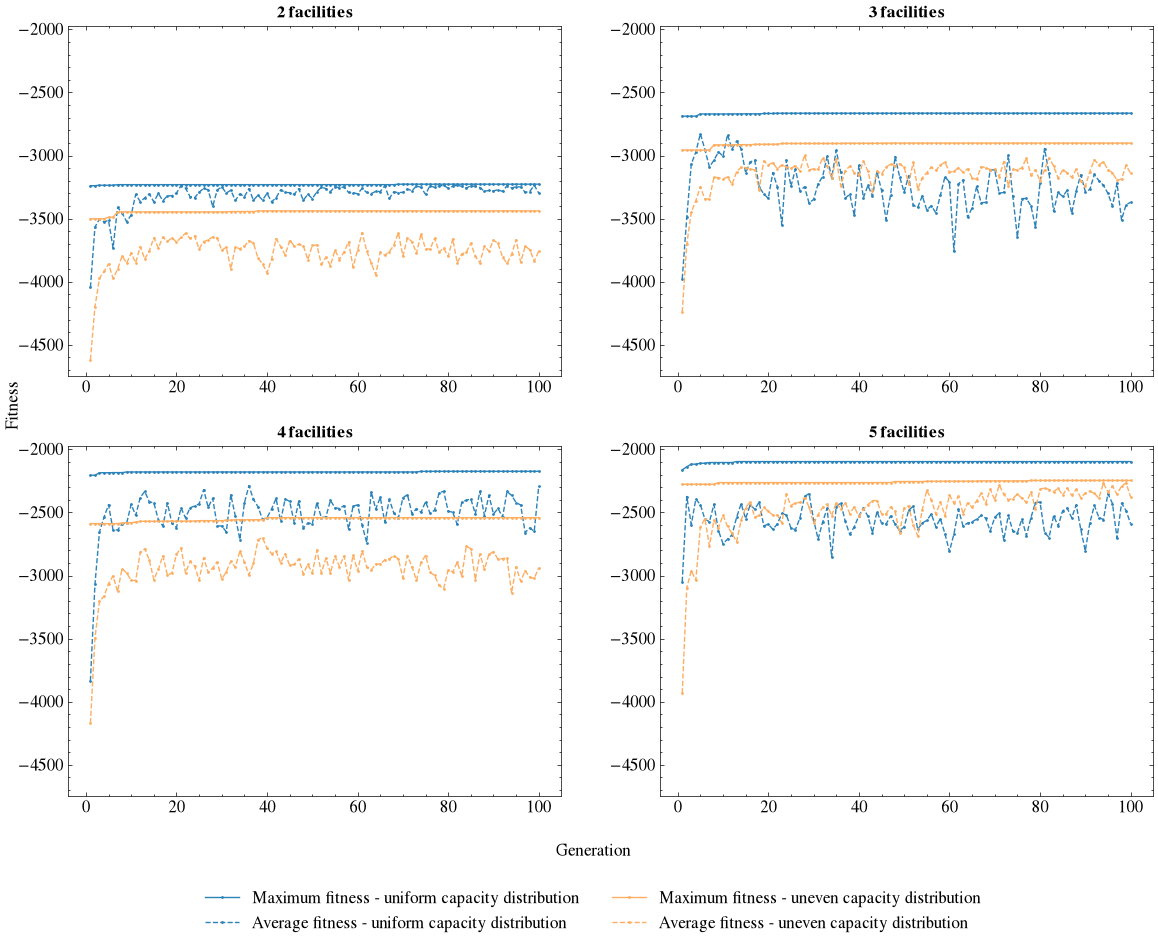

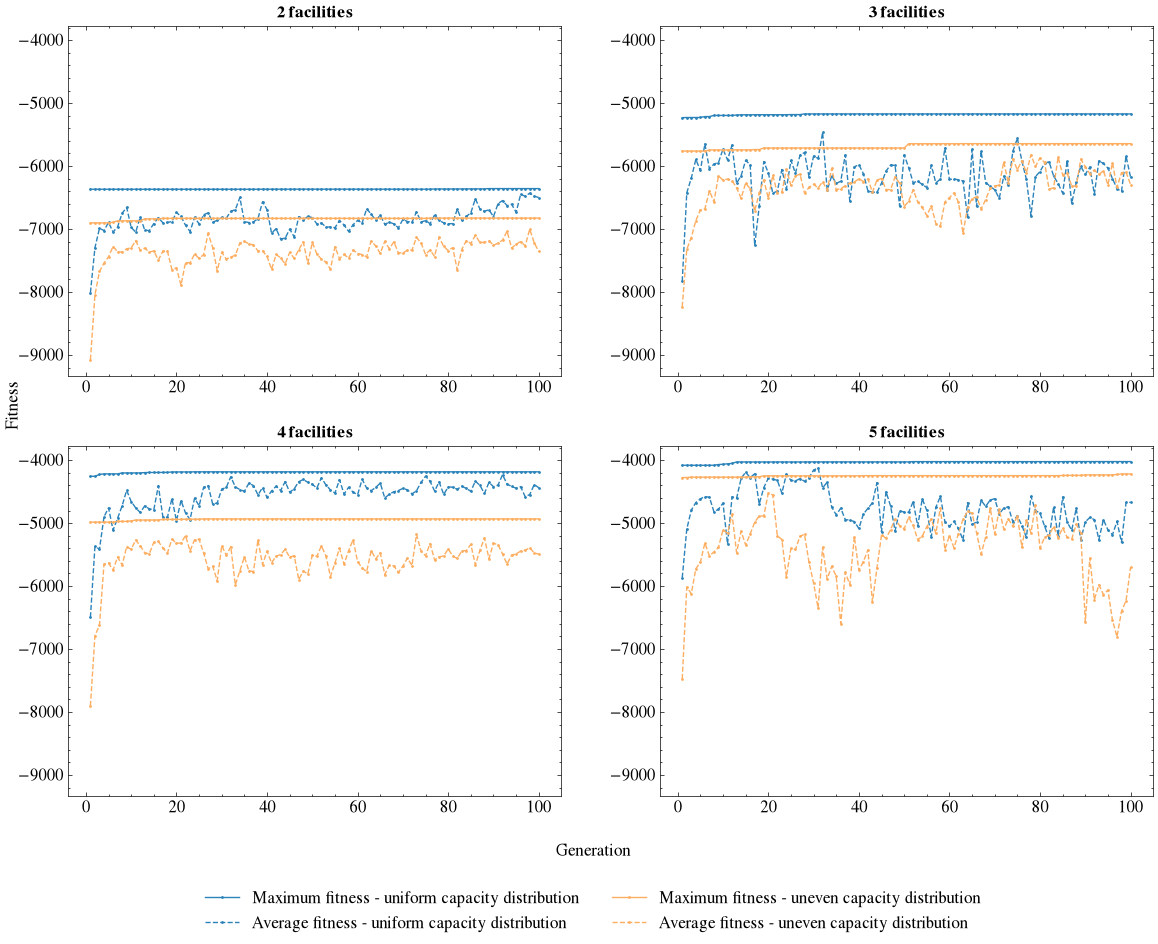

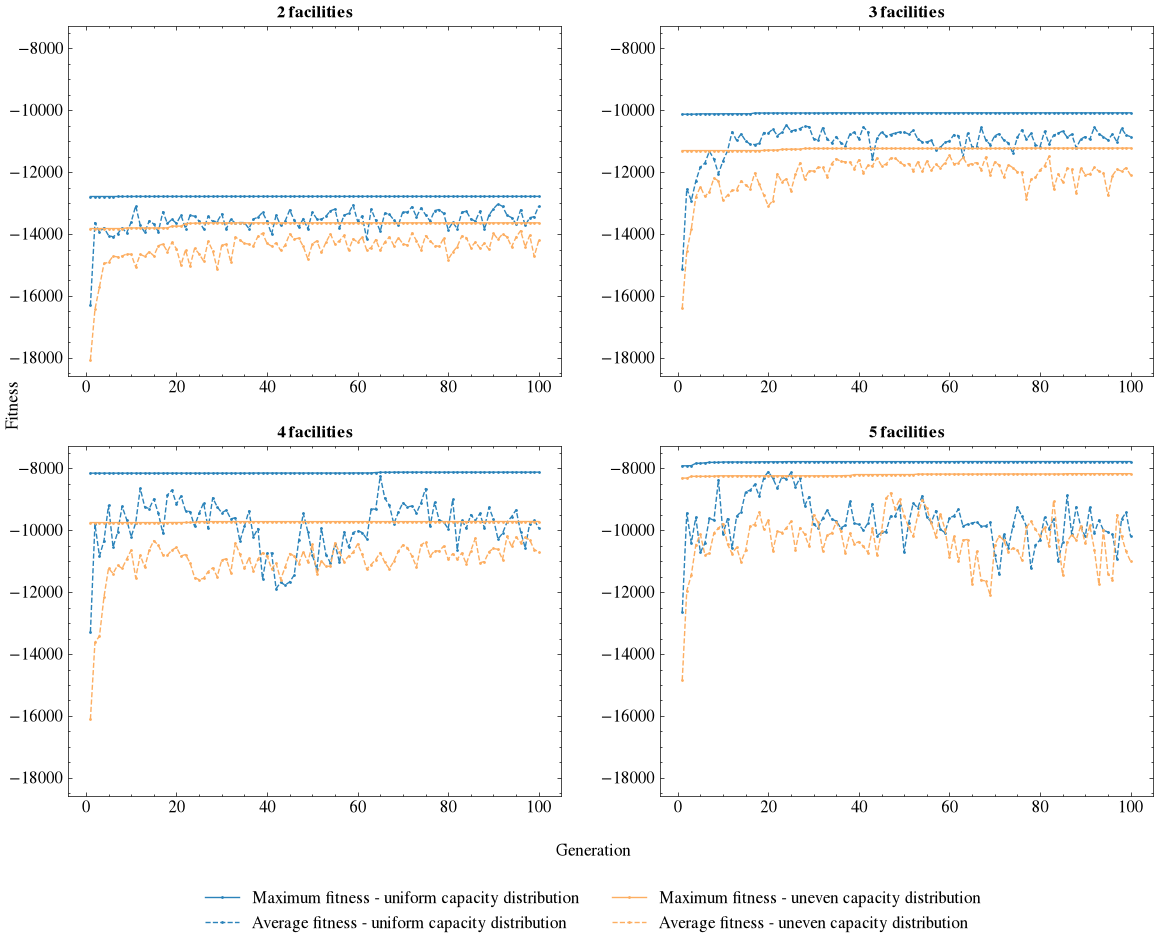

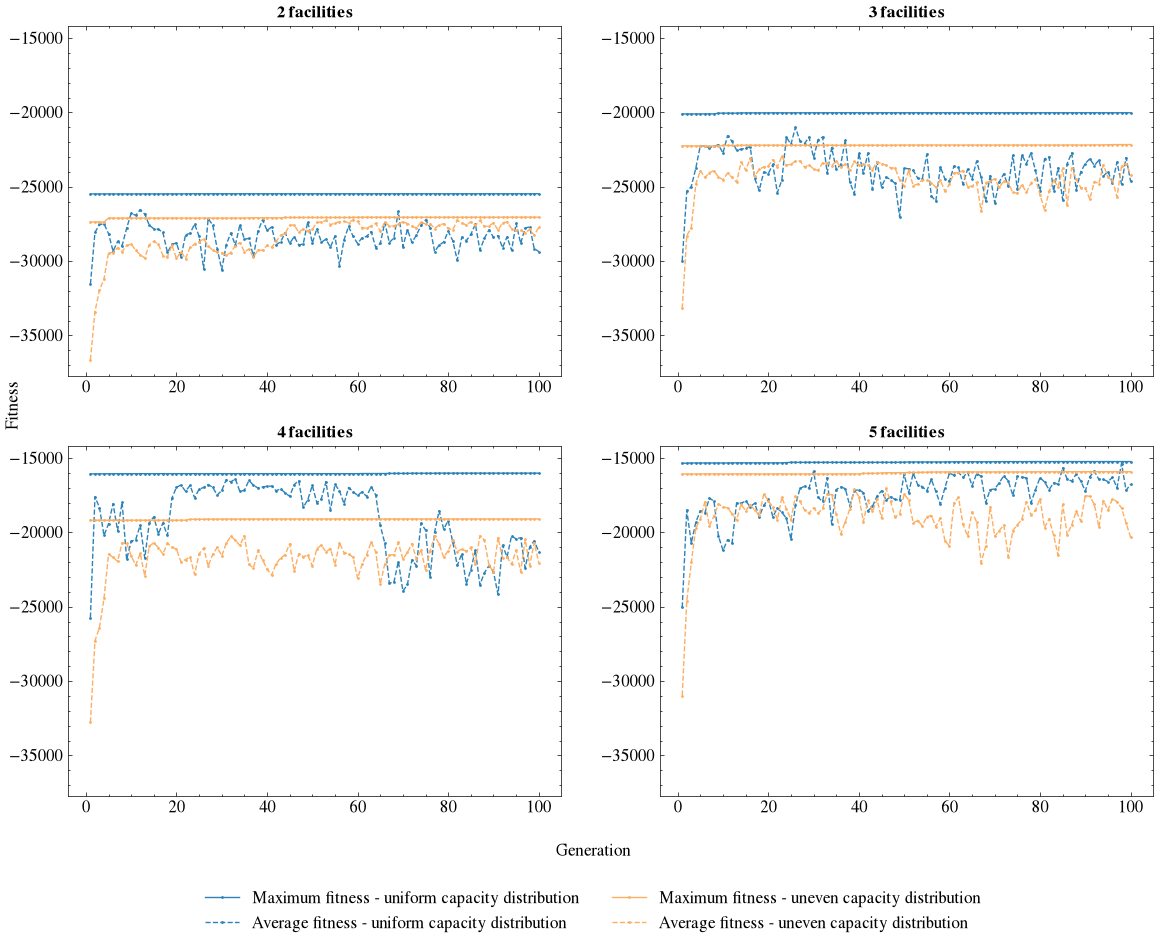

In [3]:
def gp_plot(num_customers):

    plt.rcParams['pdf.fonttype'] = 42
    plt.rcParams['ps.fonttype'] = 42

    # Create graph
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)

    num_warehouses_options = [2, 3, 4, 5]
    capacity_distribution_options = ['uniform', 'uneven']

    colors = get_colors(len(capacity_distribution_options))

    # Plot both the maximum and average fitness for each capacity distribution
    for ax, num_warehouses in zip(axes.flatten(), num_warehouses_options):
        for capacity_distribution in capacity_distribution_options:
            df = pd.read_csv(f'training/genetic_programming_training/gp_w_{num_warehouses}_c_{num_customers}_d_{capacity_distribution}_best_individuals.csv')
            grouped_df = df.groupby('generation').agg({'max_fitness': 'mean', 'avg_fitness': 'mean'}).reset_index()
            ax.plot(grouped_df['generation'], grouped_df['max_fitness'], marker='o', label=f'Maximum fitness - {capacity_distribution} capacity distribution', linestyle='solid', markersize=1, linewidth=1, color=colors[capacity_distribution_options.index(capacity_distribution)])
            ax.plot(grouped_df['generation'], grouped_df['avg_fitness'], marker='o', label=f'Average fitness - {capacity_distribution} capacity distribution', linestyle='dashed', markersize=1, linewidth=1, color=colors[capacity_distribution_options.index(capacity_distribution)])
        
        ax.set_title(f'{num_warehouses} facilities', fontweight='bold')
        ax.grid(False)
        ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
        ax.set_xticks([0, 20, 40, 60, 80, 100])
        ax.tick_params(axis='both', labelsize=FONT_SIZE_TICK, labelbottom=True, labelleft=True)

    # Set common labels
    fig.text(0.5, 0.05, 'Generation', ha='center', fontsize=FONT_SIZE_LABEL)
    fig.text(0.08, 0.5, 'Fitness', va='center', rotation='vertical', fontsize=FONT_SIZE_LABEL)

    # Add a shared legend
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.03), ncol=2, fontsize=FONT_SIZE_LEGEND)

    # Store the plot
    plt.savefig(f'training/genetic_programming_training/plots/gp_c_{num_customers}.pdf', dpi=600, bbox_inches='tight')
    plt.show()

for num_customers in num_customers_options:
    gp_plot(num_customers)

# Figures D.17 - DQN training

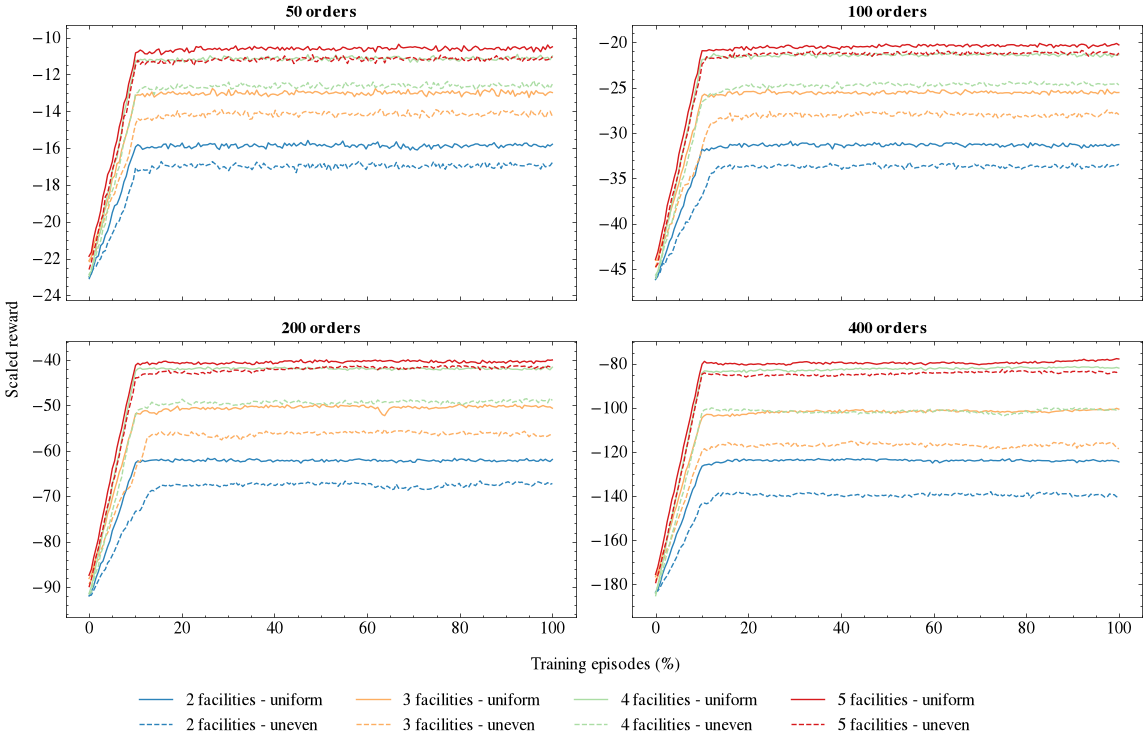

In [4]:
# Build pooled curves for one single figure
curves = {}

num_warehouses_options = [2, 3, 4, 5]
num_customers_options = [50, 100, 200, 400]
capacity_distribution_options = ["uniform", "uneven"]

# Get the curves for each combination of parameters
for num_warehouses in num_warehouses_options:
    for num_customers in num_customers_options:
        n_steps = num_customers * 50_000
        for capacity_distribution in capacity_distribution_options:
            filename = (
                f"training/deep_q_networks_training/reward_evolution/"
                f"DQN_w_{num_warehouses}_c_{num_customers}_d_{capacity_distribution}_DQN_1.csv"
            )

            df = pd.read_csv(filename).sort_values(by="Step")
            x = df["Step"].to_numpy() / n_steps * 100
            y = df["Value"].to_numpy()

            x_grid = np.linspace(0, 100, 200)
            y_interp = np.interp(x_grid, x, y)

            curves.setdefault((num_customers, num_warehouses, capacity_distribution), []).append(y_interp)

warehouse_colors = dict(zip(num_warehouses_options, get_colors(len(num_warehouses_options))))
distribution_linestyles = {"uniform": "-", "uneven": "--"}

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=False)
axes = np.atleast_1d(axes).flatten()
x_grid = np.linspace(0, 100, 200)

# Plot the curves for each number of customers, with different lines for each combination of number of warehouses and capacity distribution
for ax, num_customers in zip(axes, num_customers_options):
    y_min, y_max = np.inf, -np.inf

    for num_warehouses in num_warehouses_options:
        for capacity_distribution in capacity_distribution_options:
            ys = curves.get((num_customers, num_warehouses, capacity_distribution), [])
            if not ys:
                continue

            y_mean = np.mean(np.vstack(ys), axis=0)
            y_min = min(y_min, np.min(y_mean))
            y_max = max(y_max, np.max(y_mean))

            ax.plot(
                x_grid,
                y_mean,
                label=f"{num_warehouses} facilities - {capacity_distribution}",
                color=warehouse_colors[num_warehouses],
                linestyle=distribution_linestyles[capacity_distribution],
            )

    ax.set_title(f"{num_customers} orders", fontweight="bold")
    ax.grid(False)
    ax.tick_params(axis="both", labelsize=FONT_SIZE_TICK)
    ax.set_ylim(y_min * 1.05, y_max * 0.9)

fig.text(0.54, 0.10, "Training episodes (%)", ha="center", fontsize=FONT_SIZE_LABEL)
fig.text(0.04, 0.5, "Scaled reward", va="center", rotation="vertical", fontsize=FONT_SIZE_LABEL)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles=handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.00),
    ncol=4,
    fontsize=FONT_SIZE_LEGEND,
    title_fontsize=FONT_SIZE_LEGEND_TITLE,
)

plt.tight_layout(rect=[0.05, 0.12, 1, 0.95])
plt.savefig(
    "training/deep_q_networks_training/plots/dqn_reward_evolution_all.pdf",
    bbox_inches="tight",
    dpi=600,
)
plt.show()

# Figures D.18 - PPO training

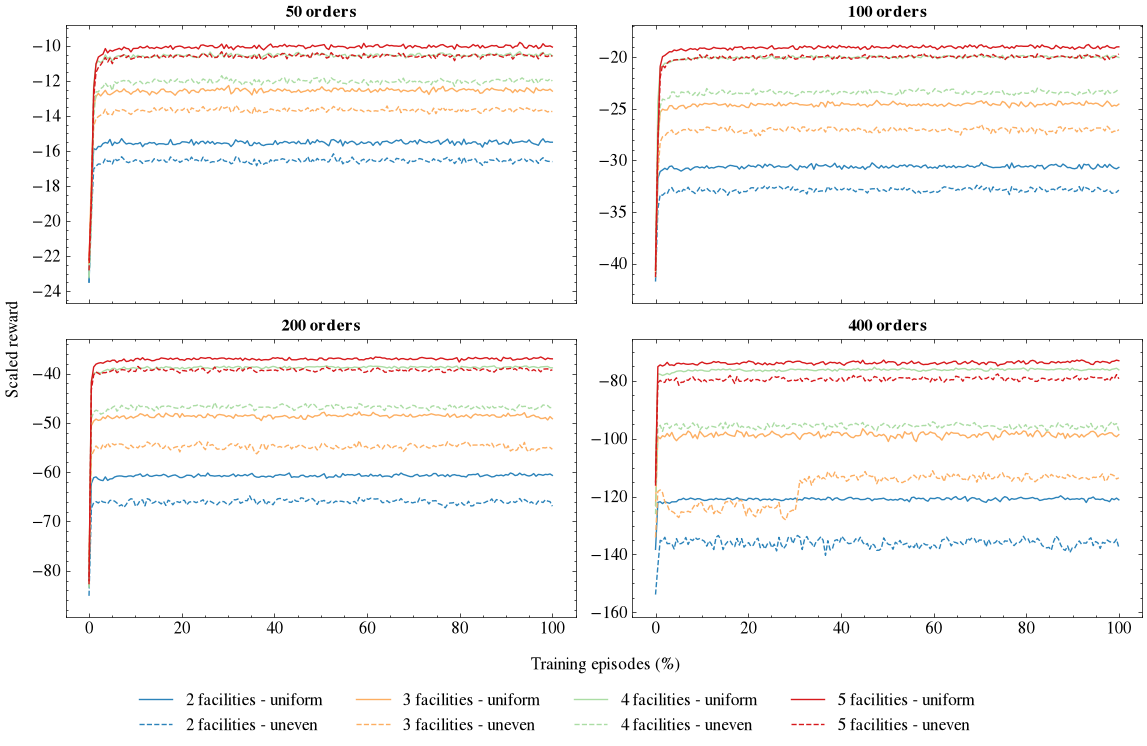

In [5]:
# Build pooled curves for one single figure
curves = {}

num_warehouses_options = [2, 3, 4, 5]
num_customers_options = [50, 100, 200, 400]
capacity_distribution_options = ["uniform", "uneven"]

# Get the curves for each combination of parameters
for num_warehouses in num_warehouses_options:
    for num_customers in num_customers_options:
        n_steps = num_customers * 50_000
        for capacity_distribution in capacity_distribution_options:
            filename = (
                f"training/proximal_policy_optimization_training/reward_evolution/"
                f"PPO_w_{num_warehouses}_c_{num_customers}_d_{capacity_distribution}_MaskablePPO_1.csv"
            )

            df = pd.read_csv(filename).sort_values(by="Step")
            x = df["Step"].to_numpy() / n_steps * 100
            y = df["Value"].to_numpy()

            x_grid = np.linspace(0, 100, 200)
            y_interp = np.interp(x_grid, x, y)

            curves.setdefault((num_customers, num_warehouses, capacity_distribution), []).append(y_interp)

# Same color code as the cell above
warehouse_colors = dict(zip(num_warehouses_options, get_colors(len(num_warehouses_options))))
distribution_linestyles = {"uniform": "-", "uneven": "--"}

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=False)
axes = np.atleast_1d(axes).flatten()
x_grid = np.linspace(0, 100, 200)

# Plot the curves for each number of customers, with different lines for each combination of number of warehouses and capacity distribution 
for ax, num_customers in zip(axes, num_customers_options):
    y_min, y_max = np.inf, -np.inf

    for num_warehouses in num_warehouses_options:
        for capacity_distribution in capacity_distribution_options:
            ys = curves.get((num_customers, num_warehouses, capacity_distribution), [])
            if not ys:
                continue

            y_mean = np.mean(np.vstack(ys), axis=0)
            y_min = min(y_min, np.min(y_mean))
            y_max = max(y_max, np.max(y_mean))

            ax.plot(
                x_grid,
                y_mean,
                label=f"{num_warehouses} facilities - {capacity_distribution}",
                color=warehouse_colors[num_warehouses],
                linestyle=distribution_linestyles[capacity_distribution],
            )

    ax.set_title(f"{num_customers} orders", fontweight="bold")
    ax.grid(False)
    ax.tick_params(axis="both", labelsize=FONT_SIZE_TICK)
    ax.set_ylim(y_min * 1.05, y_max * 0.9)

fig.text(0.54, 0.10, "Training episodes (%)", ha="center", fontsize=FONT_SIZE_LABEL)
fig.text(0.04, 0.5, "Scaled reward", va="center", rotation="vertical", fontsize=FONT_SIZE_LABEL)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles=handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.00),
    ncol=4,
    fontsize=FONT_SIZE_LEGEND,
    title_fontsize=FONT_SIZE_LEGEND_TITLE,
)

plt.tight_layout(rect=[0.05, 0.12, 1, 0.95])
plt.savefig(
    "training/proximal_policy_optimization_training/plots/ppo_reward_evolution_all.pdf",
    bbox_inches="tight",
    dpi=600,
)
plt.show()

# Figure D.16 (and related ones for the remaining families of instances) - LVFA training 

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


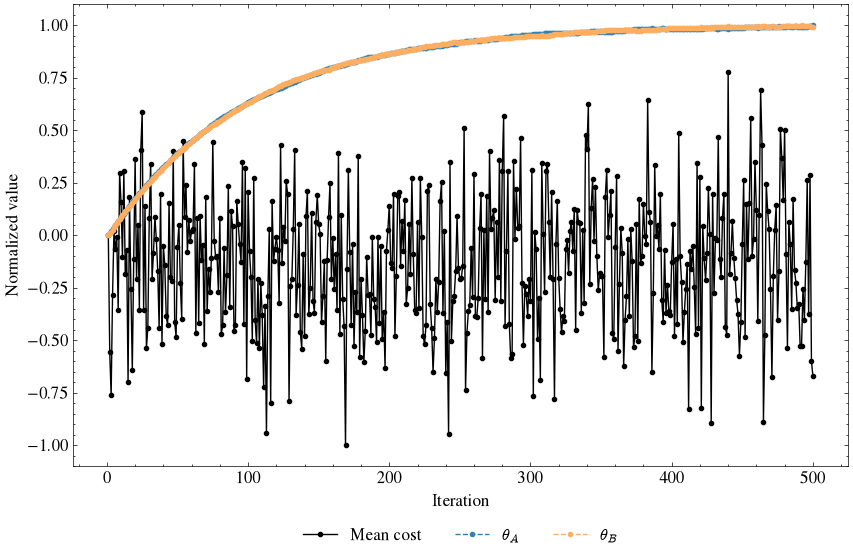

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


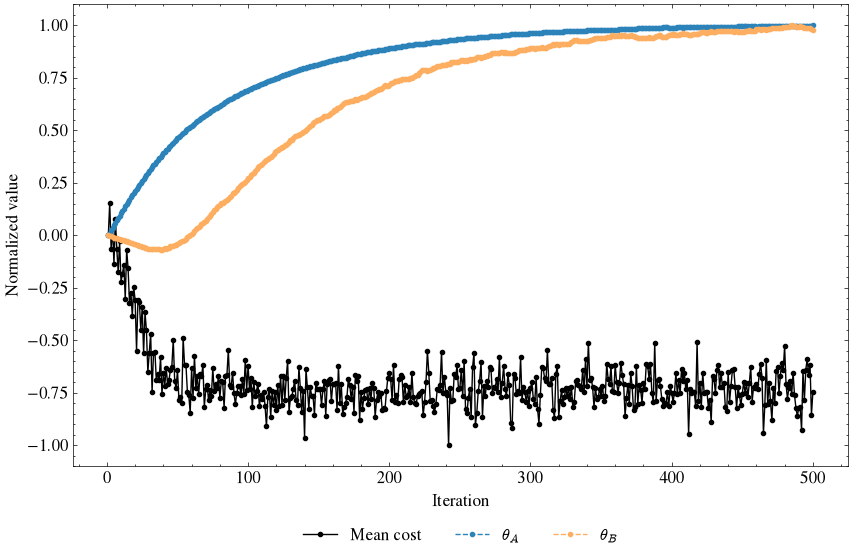

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


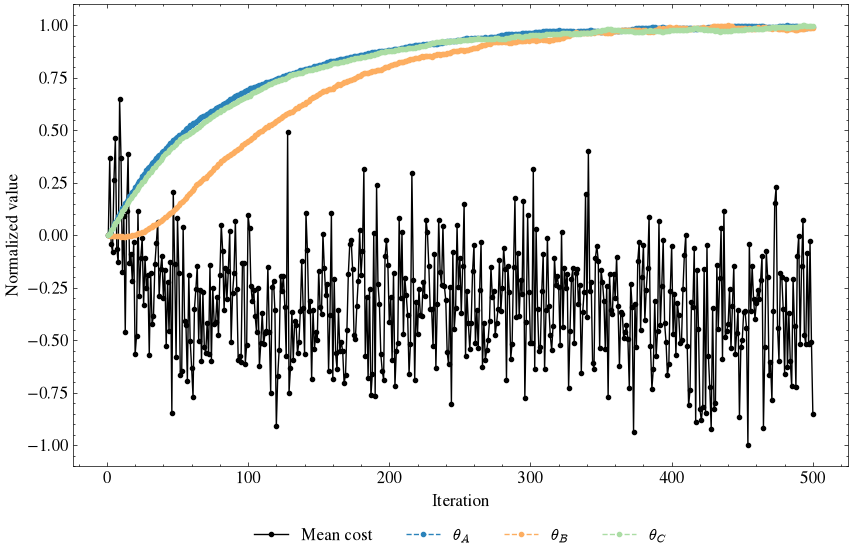

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


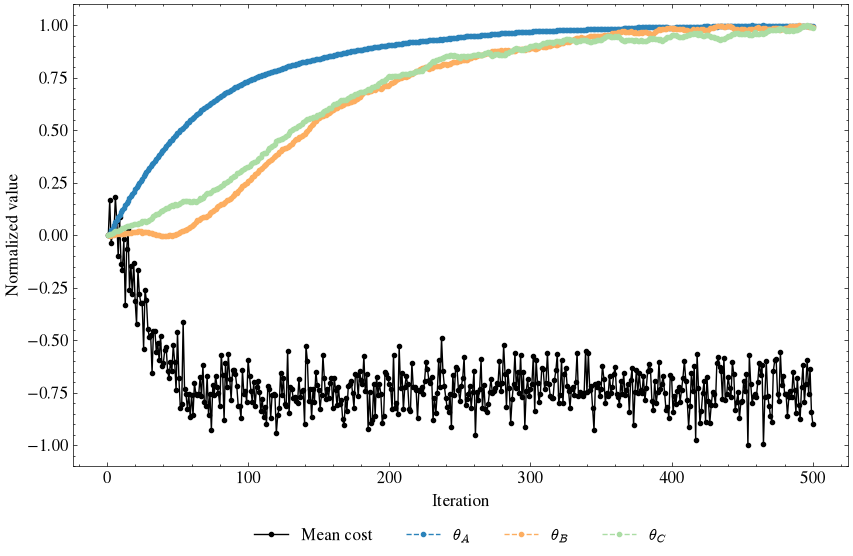

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


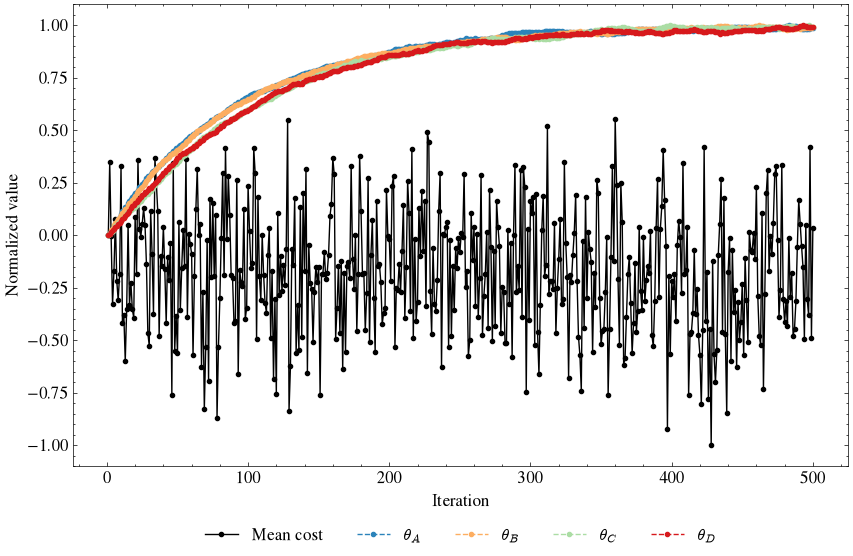

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


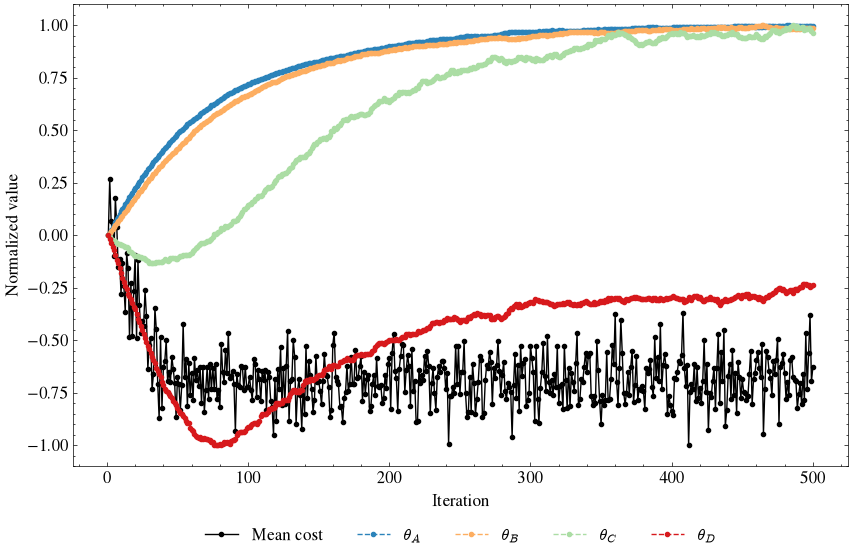

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


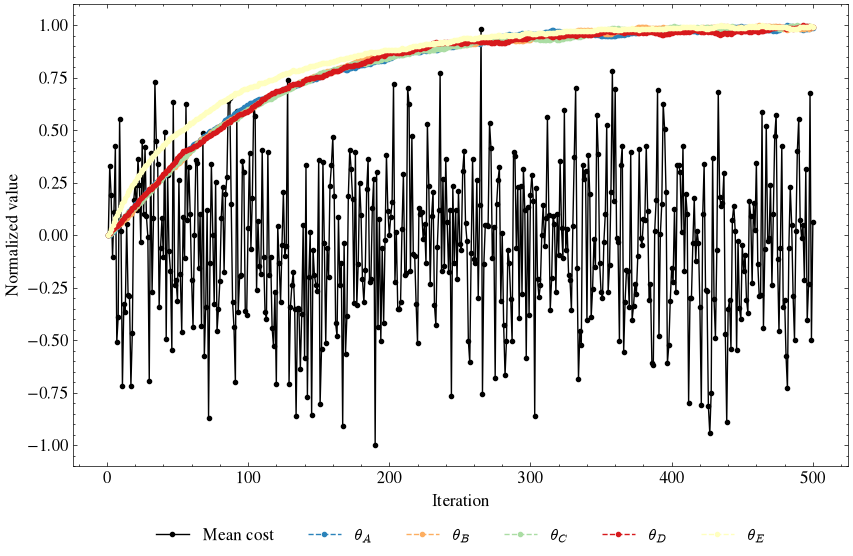

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


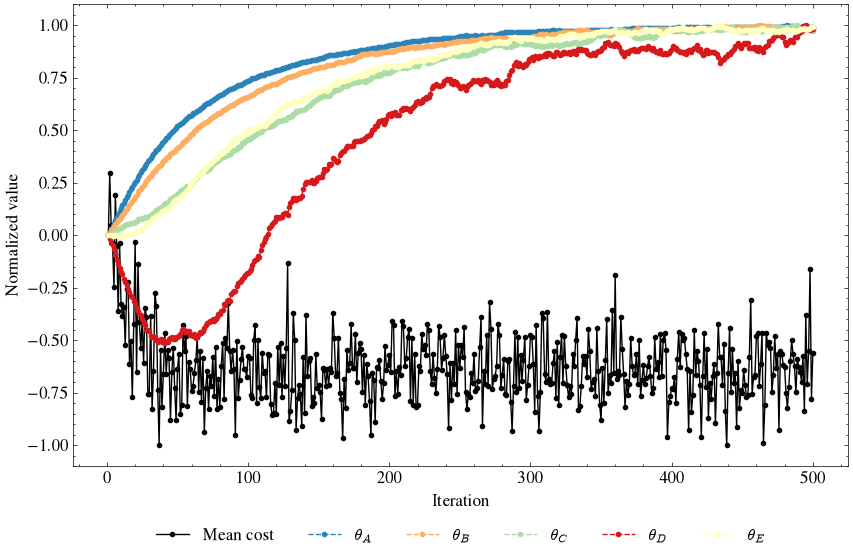

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


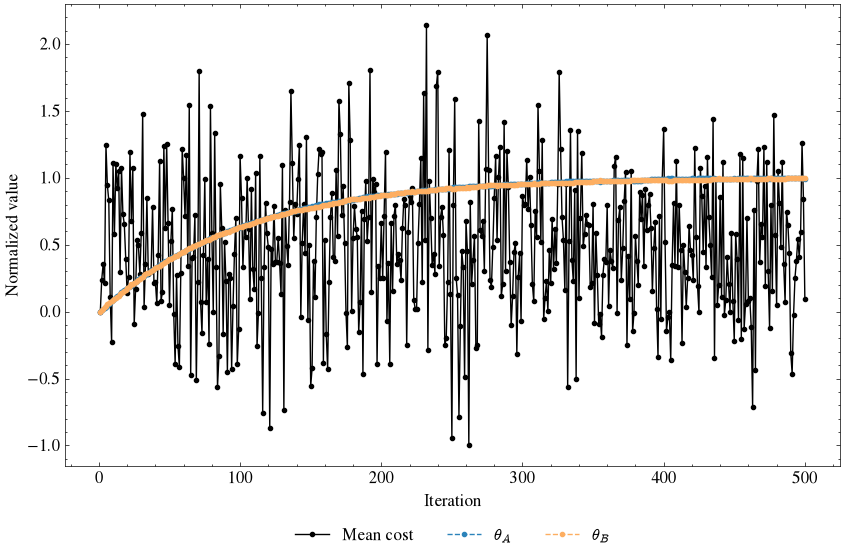

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


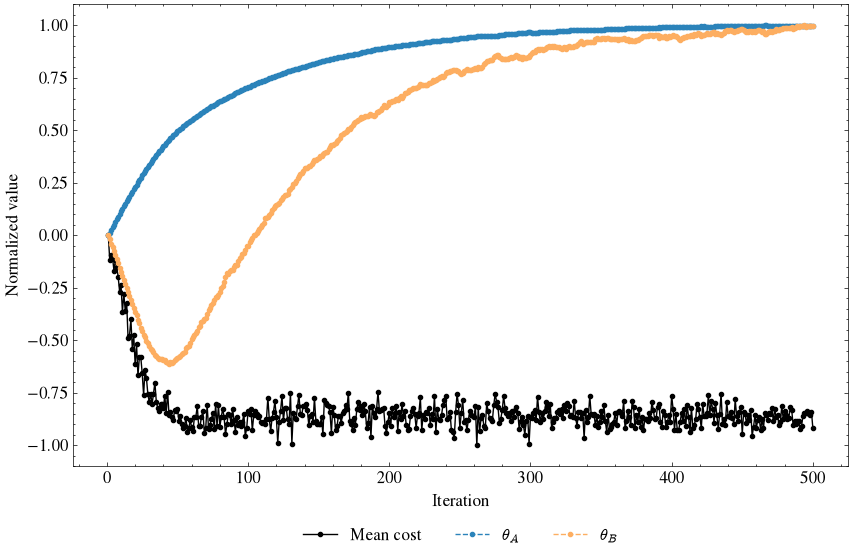

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


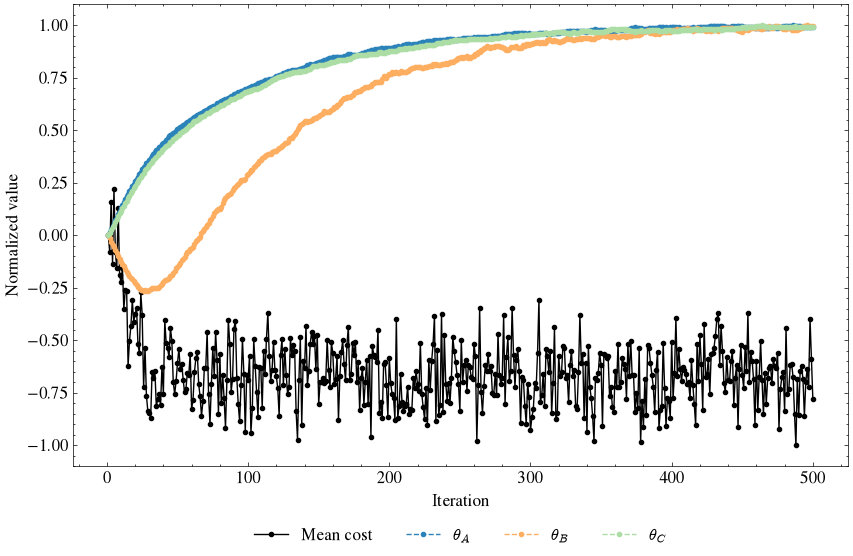

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


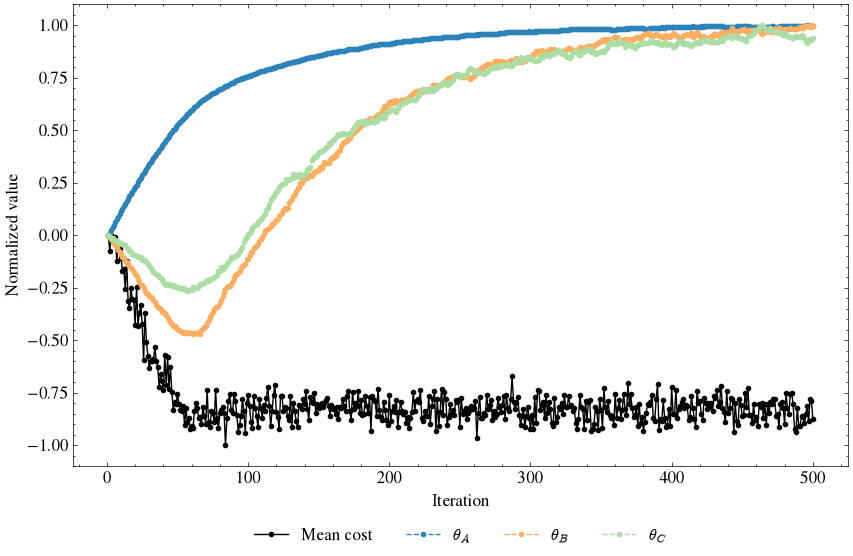

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


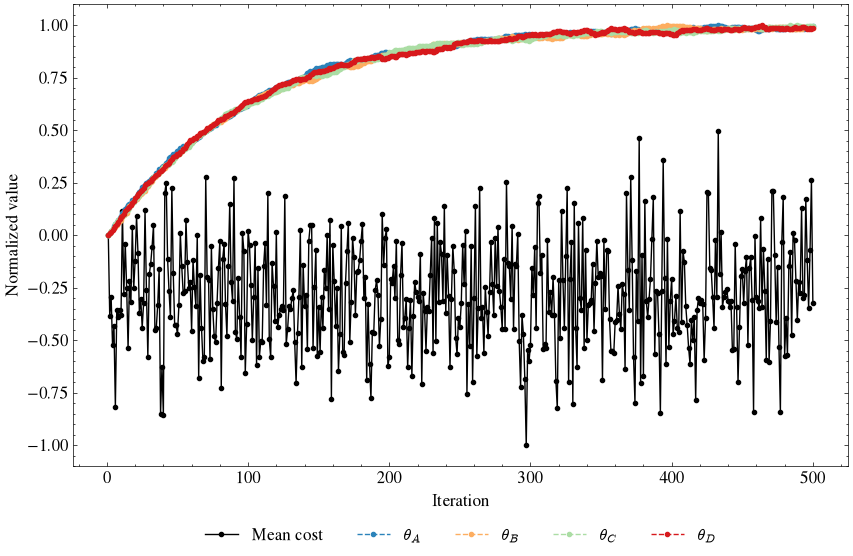

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


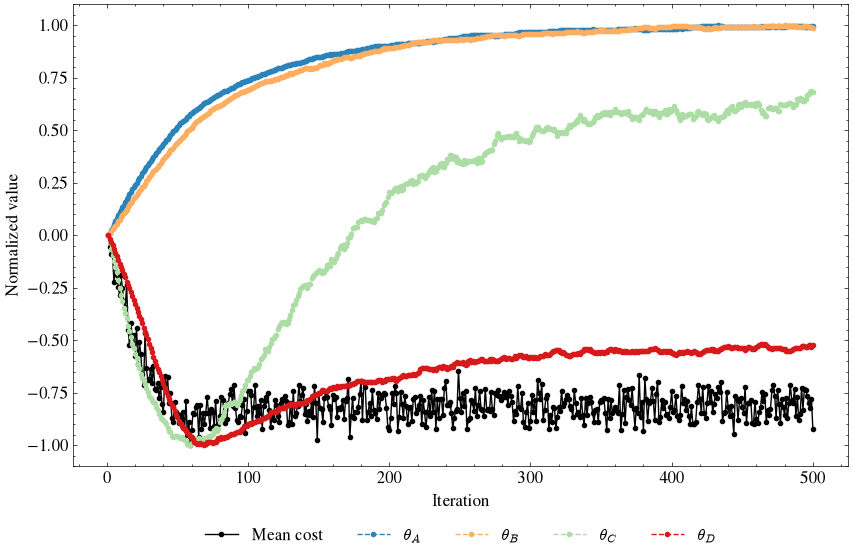

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


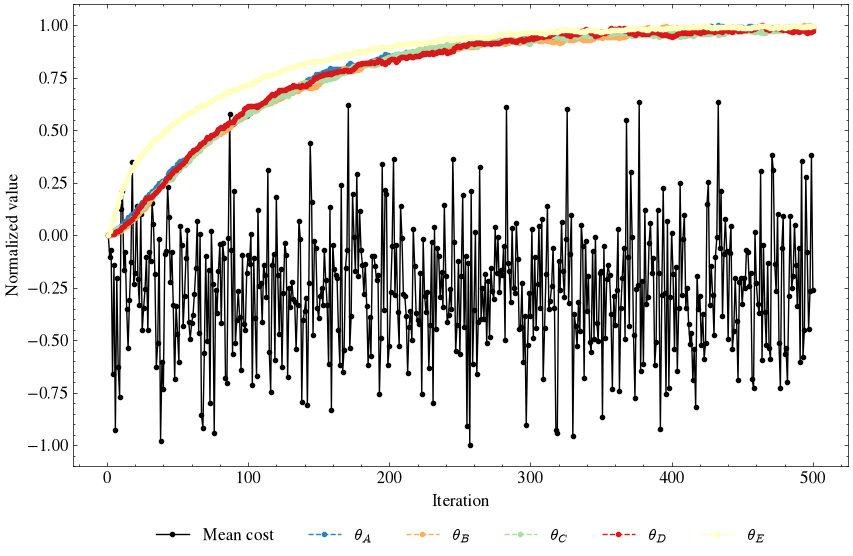

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


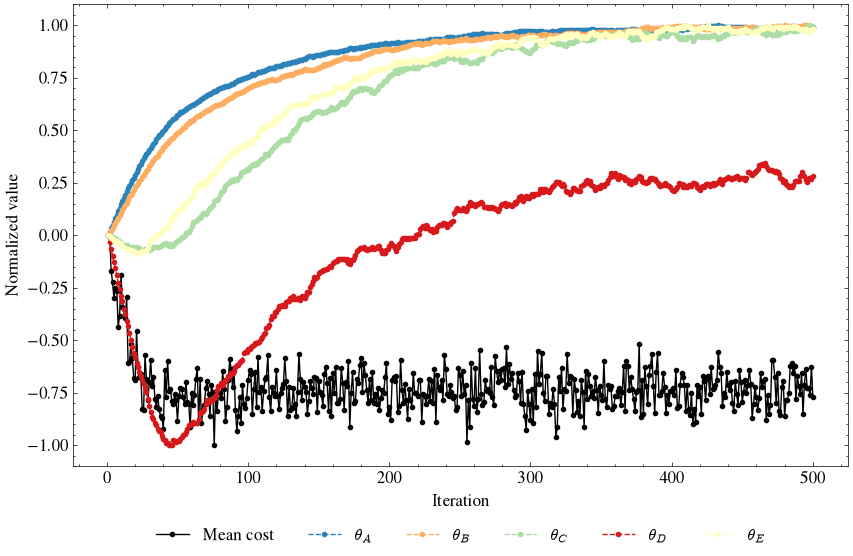

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


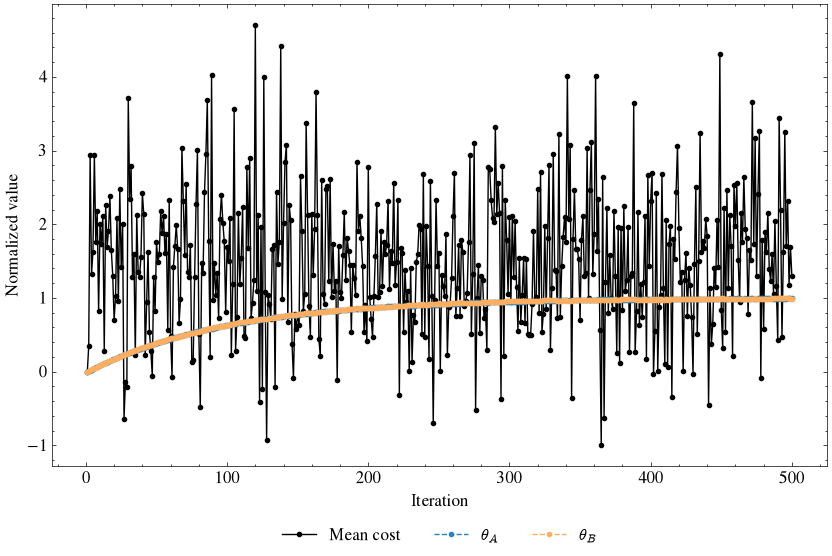

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


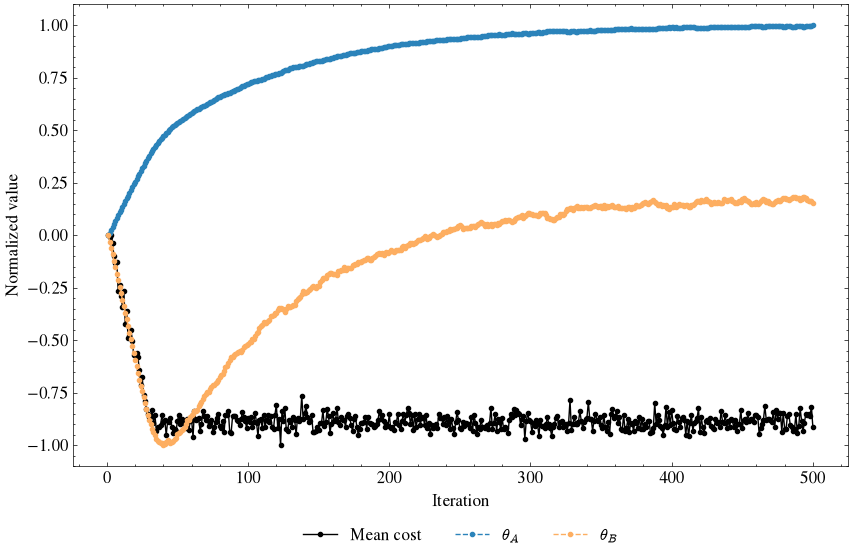

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


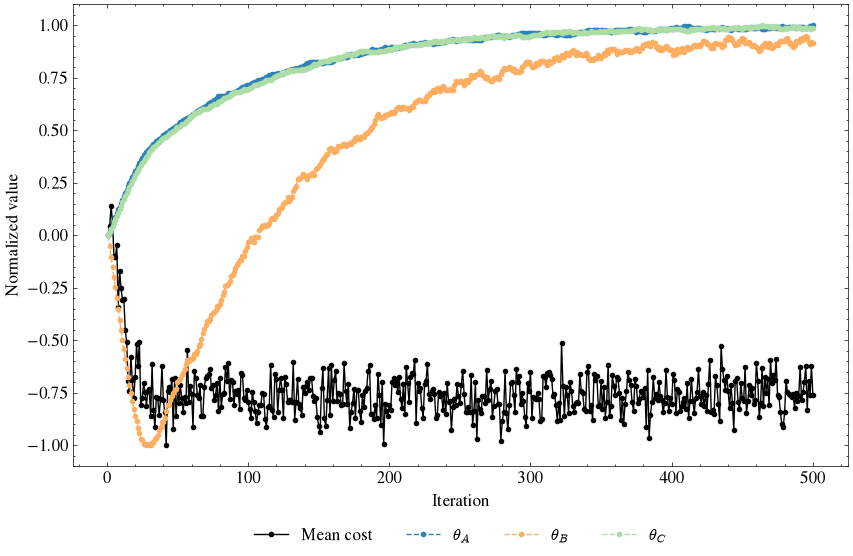

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


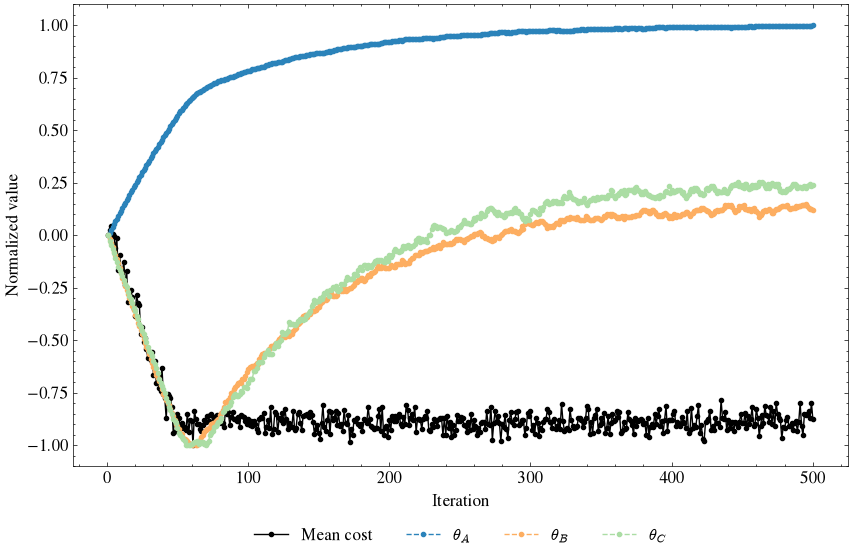

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


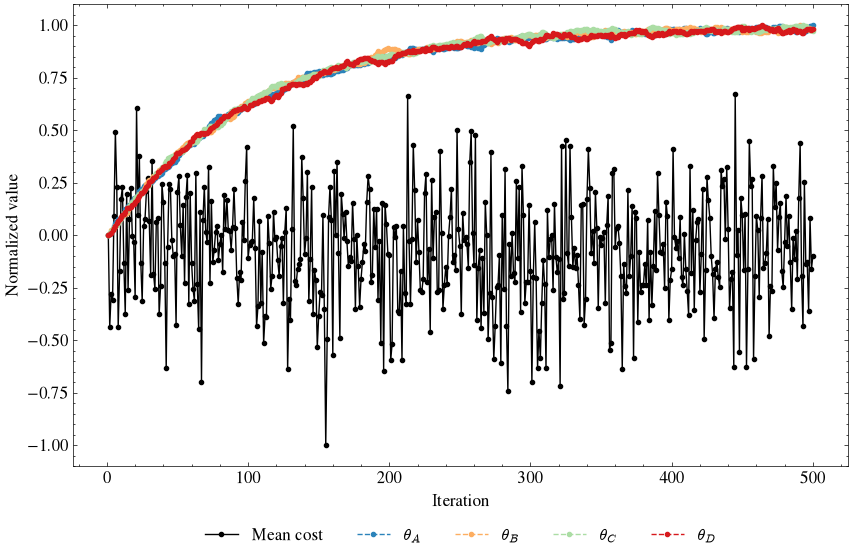

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


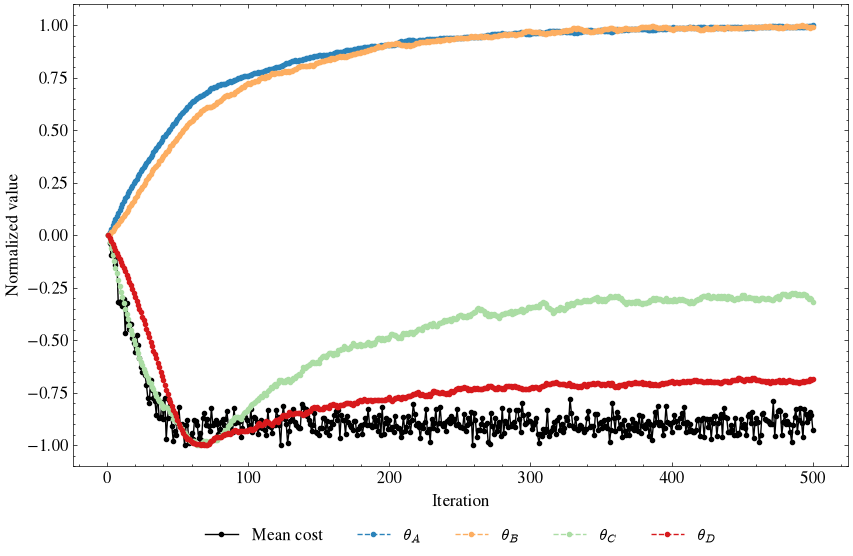

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


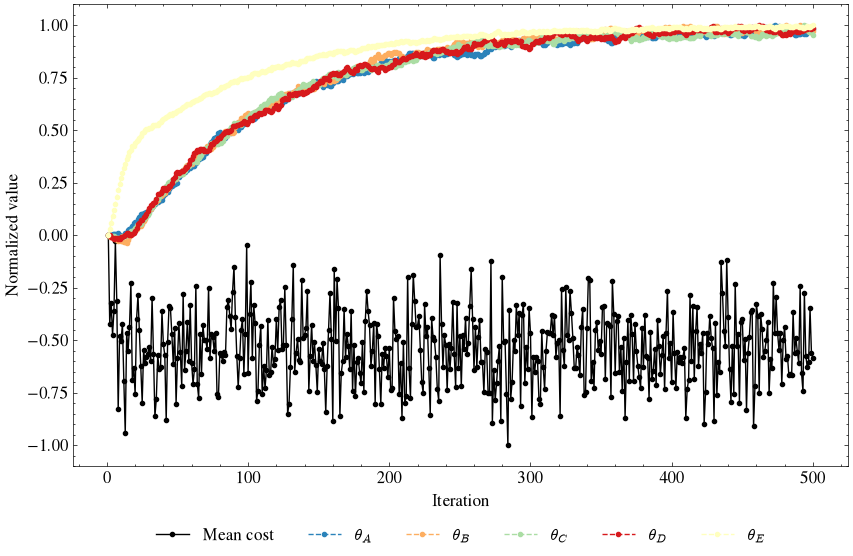

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


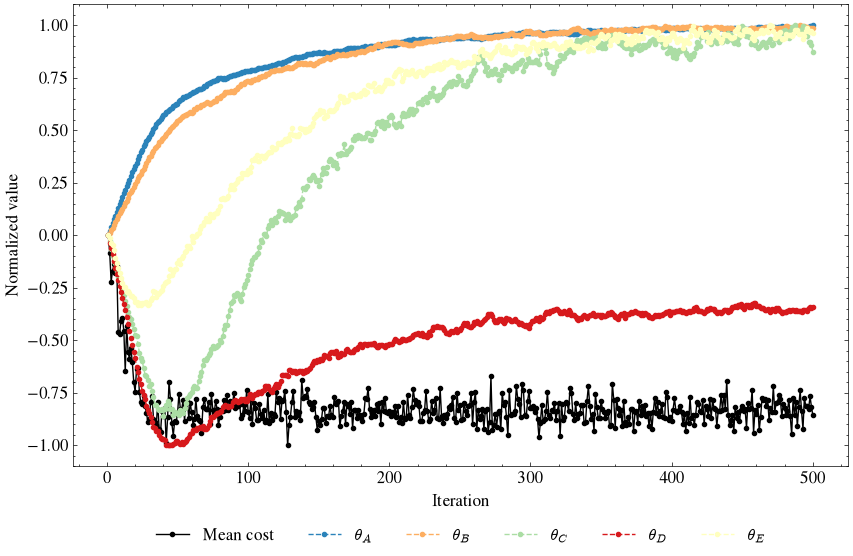

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


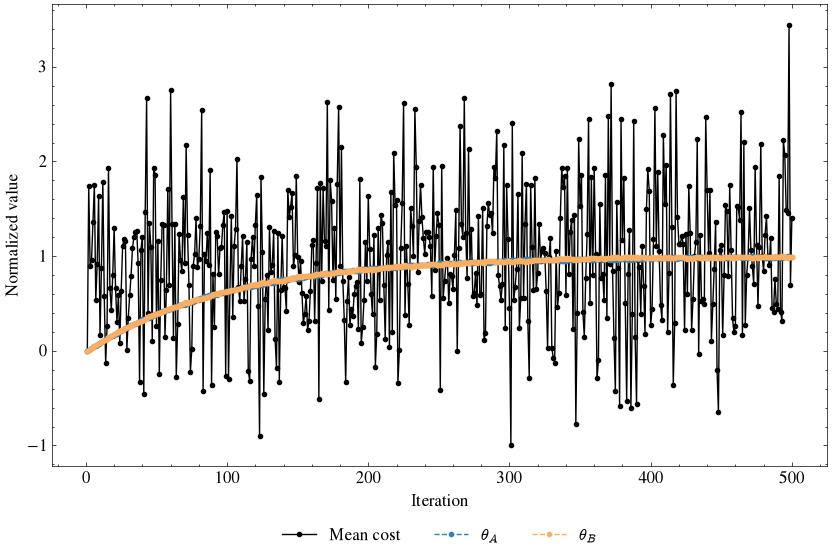

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


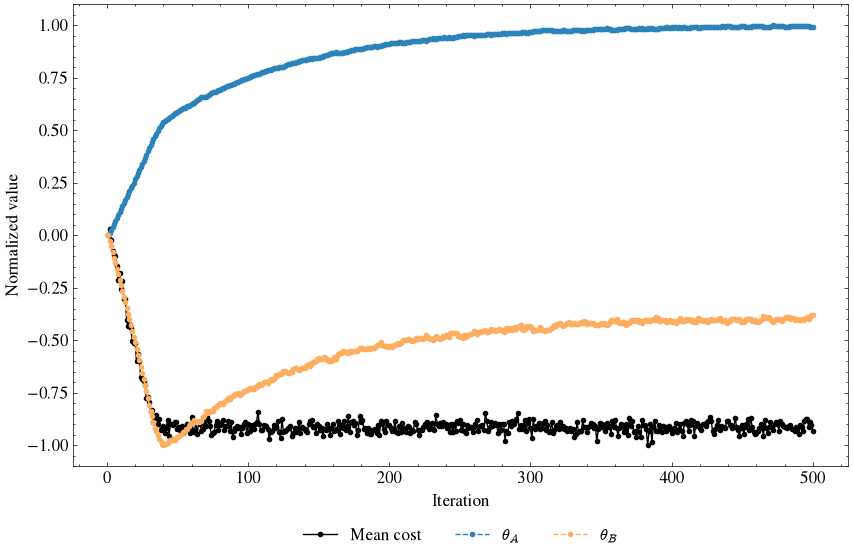

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


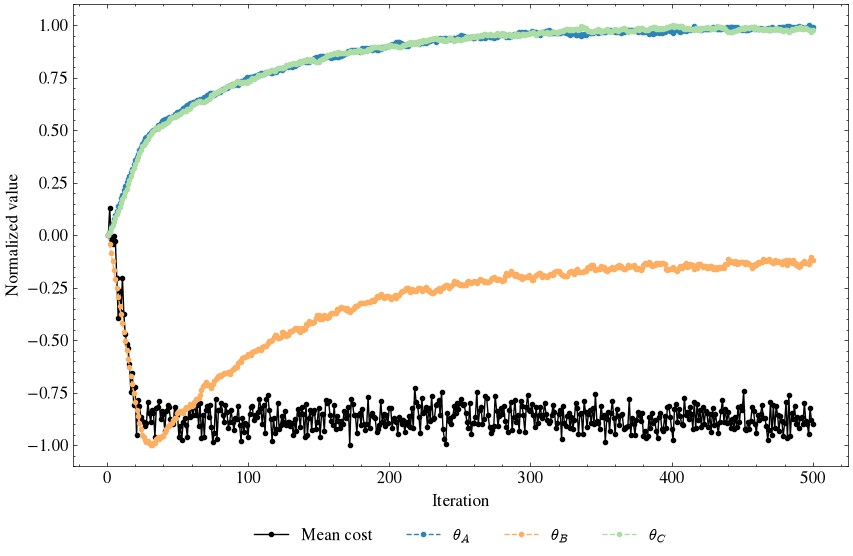

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


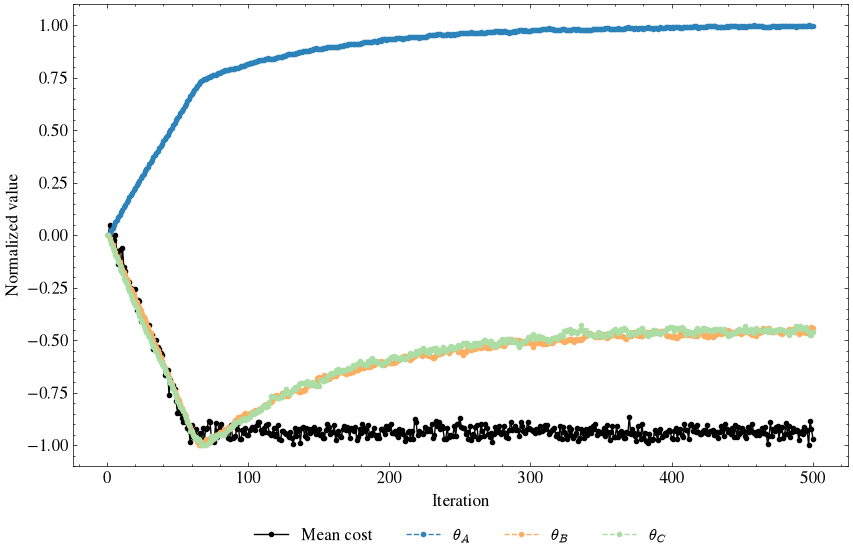

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


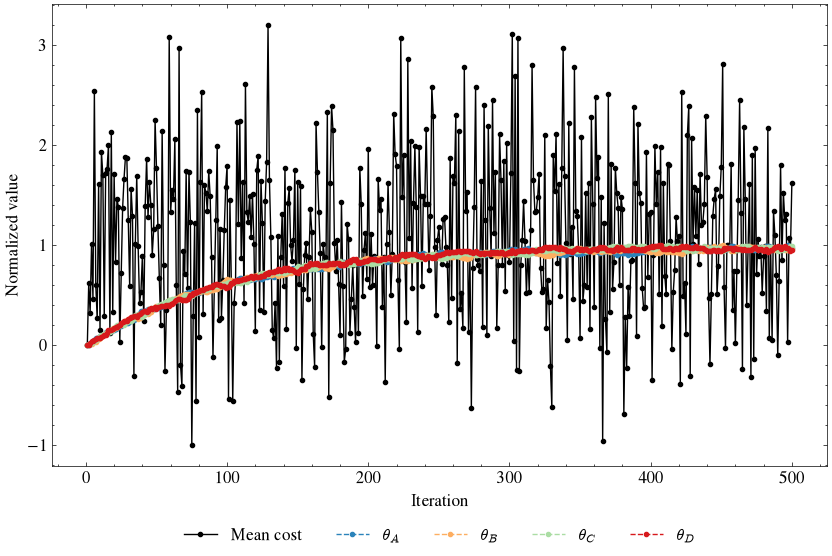

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


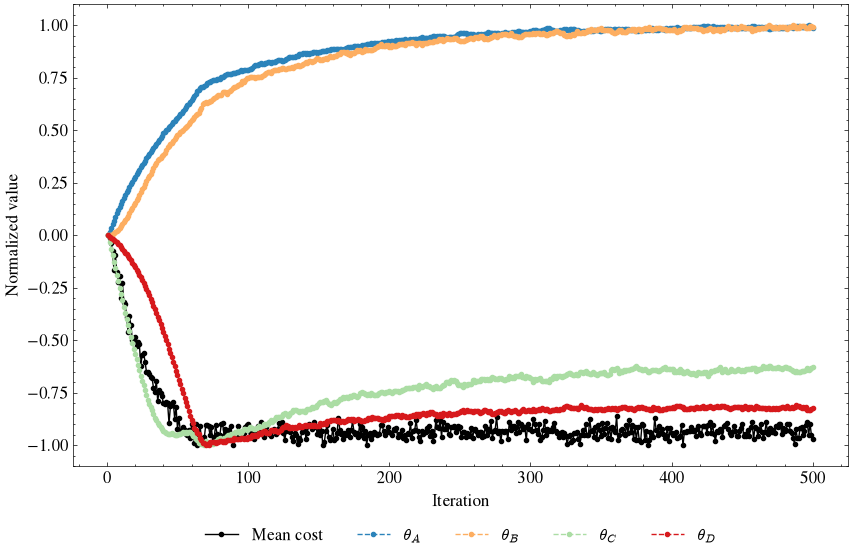

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


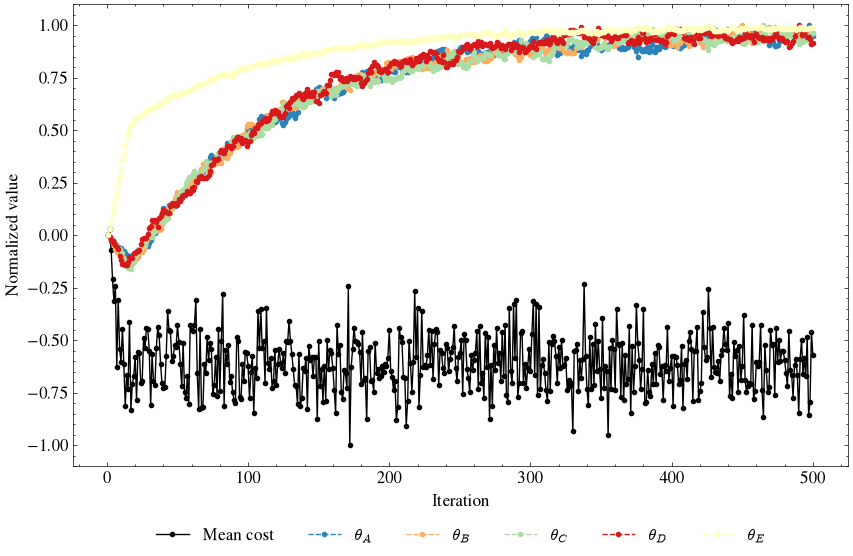

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


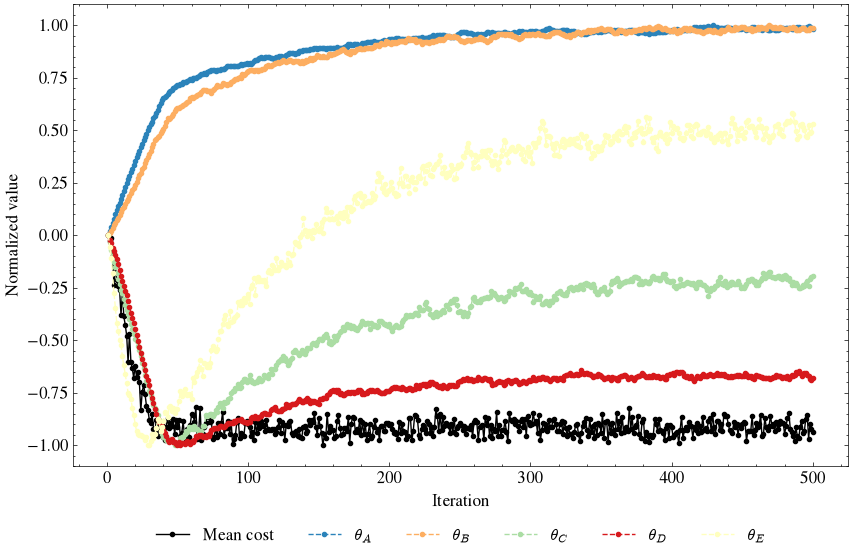

In [6]:
def lvfa_plot(num_warehouses, num_customers, capacity_distribution, normalize=False, show_theta_convergence=False, show_cost= False):

    plt.figure(figsize=(10, 6))

    # Get the evolution of the mean cost and the evolution of the theta coefficients from the CSV file
    data = pd.read_csv(f'training/linear_value_function_approximation_training/lvfa_improved_evolution_w_{num_warehouses}_c_{num_customers}_d_{capacity_distribution}.csv')

    # Plot the mean cost if requested
    if show_cost:
        mean_cost = data['mean_cost']
        min_cost = min(mean_cost)
        # Normalize the mean cost if requested
        if normalize:
            first_cost = mean_cost.iloc[0]
            denom = first_cost - min_cost
            mean_cost = (mean_cost - first_cost) / denom

        plt.plot(data['iteration'], mean_cost, marker='.', linestyle='-', color='black', label='Mean cost')

    # Plot the evolution of the theta coefficients if requested
    if show_theta_convergence:
        theta_matrix = np.array([list(map(float, row.split(','))) for row in data['theta']])
        # Normalize each coefficient by its own max absolute value across iterations
        max_abs = np.max(np.abs(theta_matrix), axis=0)
        normalized_theta = theta_matrix / max_abs

        theta_colors = get_colors(normalized_theta.shape[1])
        for coef_idx in range(normalized_theta.shape[1]):
            plt.plot(
                data['iteration'],
                normalized_theta[:, coef_idx],
                marker='.',
                linestyle='--',
                color=theta_colors[coef_idx],
                label=rf'$\theta_{{{chr(65 + coef_idx)}}}$'
            )

    plt.xlabel('Iteration', fontsize=FONT_SIZE_LABEL)
    plt.ylabel('Normalized value' if (normalize or show_theta_convergence) else 'Mean Cost', fontsize=FONT_SIZE_LABEL)
    plt.xticks(fontsize=FONT_SIZE_TICK)
    plt.yticks(fontsize=FONT_SIZE_TICK)
    if normalize or show_theta_convergence:
        plt.legend(fontsize=FONT_SIZE_LEGEND, loc='upper center', bbox_to_anchor=(0.5, -0.10), ncol=num_warehouses + (1 if show_cost else 0))
    plt.grid(False)

    # Save the plot
    out_dir = 'training/linear_value_function_approximation_training/plots'
    os.makedirs(out_dir, exist_ok=True)
    plt.savefig(f'{out_dir}/lvfa_improved_evolution_w_{num_warehouses}_c_{num_customers}_{capacity_distribution}.pdf', dpi=600, bbox_inches='tight')

    plt.show()

# Get the mean cost and theta convergence plots for all combinations of parameters
num_warehouses_options = [2, 3, 4, 5]
num_customers_options = [50, 100, 200, 400]
capacity_distribution_options = ['uniform', 'uneven']

for num_customers in num_customers_options:
    for num_warehouses in num_warehouses_options:
        for capacity_distribution in capacity_distribution_options:
            lvfa_plot(num_warehouses, num_customers, capacity_distribution, normalize=True, show_theta_convergence=True, show_cost=True)

From this point onward, the optimal policy is used. Its value tables are very large (over 15 GB in total), so they do not fit in the GitHub repository. However, training is fast thanks to parallelization. All instances with 50 orders, which are the ones used in the cells below, can be solved in under 2 minutes. To do so, run `train_exact_value_function.py` in the `training/` folder.

# Figure 11 -> Cumulative cost comparison between the MYO and OPT policies

In [7]:
from env import InventoryEnv
from policies.exact_value_function_policy import ExactValueFunctionPolicy
from training.train_exact_value_function import aggregate_state

NUM_EPISODES = 500
NUM_REPLICATIONS = 100
EVF_SEED_START = 40001  # np.random seed for the very first episode; increments by 1 every episode thereafter

# Run one episode of the optimal policy (exact value function policy) and return the total reward obtained in that episode.
def run_exact_value_function_episode(env, policy):
  
    policy.reset(None)
    state, info = env.reset()

    done = False
    final_reward = 0.0
    while not done:
        action = policy.act(state)
        state, reward, done, truncated, _ = env.step(action)
        final_reward += reward

    return final_reward

# Perform multiple replications of the exact value function policy and return the baseline value and the running averages of the rewards obtained in each episode across all replications.
def exact_value_function_convergence(num_warehouses, num_customers, capacity_distribution,
                                      num_episodes=NUM_EPISODES, num_replications=NUM_REPLICATIONS):
    env = InventoryEnv(num_warehouses, num_customers, capacity_distribution, grid_size=200)
    env.set_instance(None)  # draw a fresh random customer sequence per episode via env.create_customer()

    policy = ExactValueFunctionPolicy(env, num_warehouses, num_customers, capacity_distribution)
    baseline = policy.values[aggregate_state(tuple(env.warehouses_initial_capacity), policy.aggregation)]

    seed = EVF_SEED_START
    running_averages = np.zeros((num_replications, num_episodes))
    for rep in range(num_replications):
        rewards = np.empty(num_episodes)
        for ep in range(num_episodes):
            env.set_seed(seed)  # re-seed before every episode to ensure reproducibility
            seed += 1           # increment the seed for the next episode
            rewards[ep] = run_exact_value_function_episode(env, policy)
        # Compute the running average of rewards for this replication
        running_averages[rep] = np.cumsum(rewards) / np.arange(1, num_episodes + 1)

    return baseline, running_averages

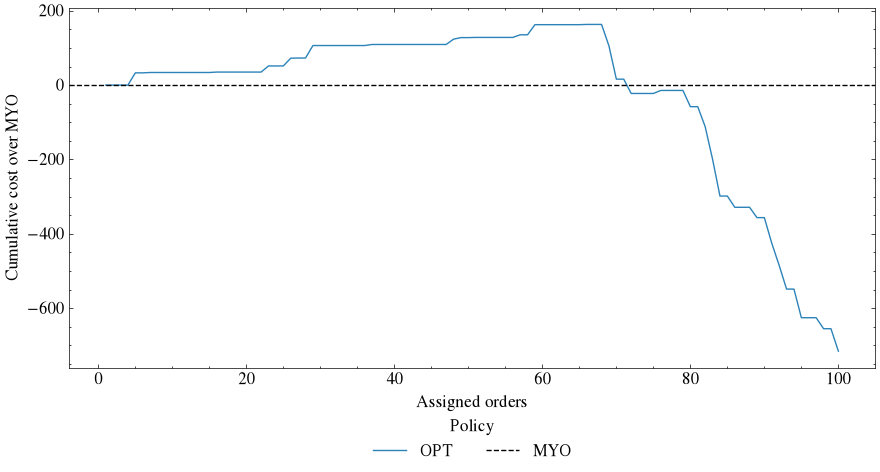

In [8]:
INSTANCE_NUM = 10001    #first instance in instances_test/
INSTANCE_FILE = f"instances/instances_test/instances_seed_{INSTANCE_NUM}.json"
NUM_WAREHOUSES = 5
NUM_CUSTOMERS = 100
CAPACITY_DISTRIBUTION = "uneven"
REFERENCE_POLICY = "myopic"

SELECTED_POLICIES = {
    "myopic": lambda env: MyopicPolicy(env),
    "exact_value_function": lambda env: ExactValueFunctionPolicy(env, NUM_WAREHOUSES, NUM_CUSTOMERS, CAPACITY_DISTRIBUTION),
}

SELECTED_POLICIES_WITHOUT_BASELINE = {k: v for k, v in SELECTED_POLICIES.items() if k != REFERENCE_POLICY}

POLICY_LABELS = {
    "myopic": "MYO",
    "perfect_hindsight": "PHS",
    "point_estimate_lookahead": "PEL",
    "distributional_estimate_lookahead": "DEL",
    "genetic_programming": "GP",
    "least_squares_policy_iteration": "LSPI",
    "linear_programming_heuristic": "LPH",
    "linear_programming_exact": "LPE",
    "parameterized_lookahead_approximation": "PLA",
    "imitation_learning": "IL",
    "deep_q_networks": "DQN",
    "proximal_policy_optimization": "PPO",
    "exact_value_function": "OPT"
}

assert REFERENCE_POLICY in SELECTED_POLICIES, "REFERENCE_POLICY must be one of SELECTED_POLICIES"

from miscellaneous import read_instance
from env import InventoryEnv
from policies.myopic_policy import MyopicPolicy
from policies.exact_value_function_policy import ExactValueFunctionPolicy

instance = read_instance(INSTANCE_FILE)
policy_colors = dict(zip(SELECTED_POLICIES_WITHOUT_BASELINE.keys(), get_colors(len(SELECTED_POLICIES_WITHOUT_BASELINE))))

# Get the cumulative costs for each policy on the specific instance

cumulative_by_policy = {}

for name, make_policy in SELECTED_POLICIES.items():
    env = InventoryEnv(NUM_WAREHOUSES, NUM_CUSTOMERS, CAPACITY_DISTRIBUTION, grid_size=200)
    env.set_instance(instance)
    policy = make_policy(env)
    policy.reset(instance)
    state, info = env.reset()

    cumulative_rewards = []
    cumulative_costs = []
    cumulative_reward = 0
    done = False
    while not done:
        action = policy.act(state)
        state, reward, done, truncated, _ = env.step(action)
        cumulative_reward += reward
        cumulative_rewards.append(cumulative_reward)
        cumulative_costs.append(-cumulative_reward)

    cumulative_by_policy[name] = cumulative_costs

# The MYO policy is used as the reference policy for comparison, and its cumulative costs are stored in `reference_curve`.
reference_curve = cumulative_by_policy[REFERENCE_POLICY]

fig, ax = plt.subplots(figsize=(9, 5))

for name, cumulative_rewards in cumulative_by_policy.items():
    if name == REFERENCE_POLICY:
        continue
    steps = range(1, len(cumulative_rewards) + 1)
    advantage = [c - r for c, r in zip(cumulative_costs, reference_curve)]
    ax.plot(steps, advantage, label=POLICY_LABELS.get(name, name), color=policy_colors[name])

ax.axhline(0, color="black", linewidth=1, linestyle="--", label=POLICY_LABELS.get(REFERENCE_POLICY, REFERENCE_POLICY))
ax.set_xlabel("Assigned orders", fontsize=FONT_SIZE_LABEL)
ax.set_ylabel(f"Cumulative cost over {POLICY_LABELS.get(REFERENCE_POLICY, REFERENCE_POLICY)}", fontsize=FONT_SIZE_LABEL)
ax.tick_params(axis="both", labelsize=FONT_SIZE_TICK)
ax.legend(title="Policy", loc="lower center", bbox_to_anchor=(0.5, -0.30), ncol=3, fontsize=FONT_SIZE_LEGEND, title_fontsize=FONT_SIZE_LEGEND_TITLE)
plt.tight_layout()

# Save the plot to a file
output_dir = "results/plots/specific_instance_analysis"
os.makedirs(output_dir, exist_ok=True)
output_path = f"{output_dir}/cumulative_cost_vs_myo_instance{INSTANCE_NUM}_w{NUM_WAREHOUSES}_c{NUM_CUSTOMERS}_{CAPACITY_DISTRIBUTION}.pdf"
fig.savefig(output_path, dpi=600, bbox_inches="tight")
plt.show()

# Figure C.13 (and similar figures for the remaining families of instances) -> Impact of number of episodes in the quality of approximation of the expectation

Running exact value function convergence for 2 warehouses, 50 customers, uniform capacity distribution


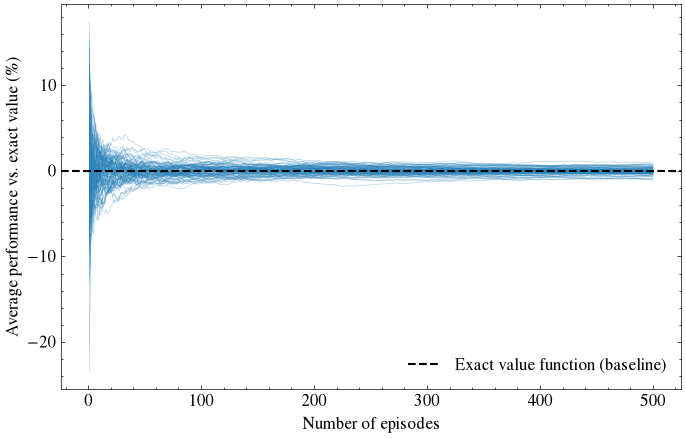

Running exact value function convergence for 2 warehouses, 50 customers, uneven capacity distribution


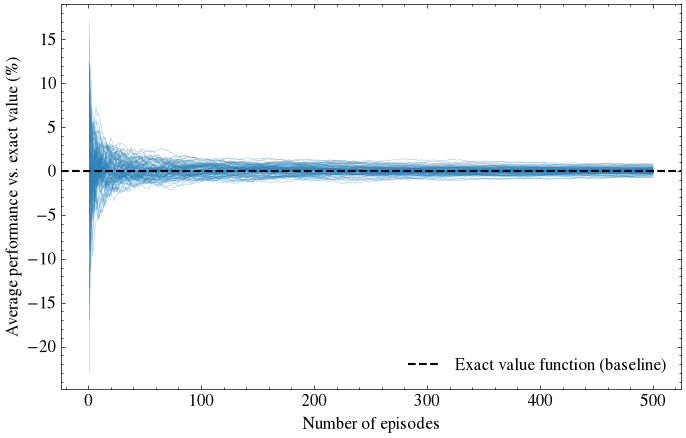

Running exact value function convergence for 3 warehouses, 50 customers, uniform capacity distribution


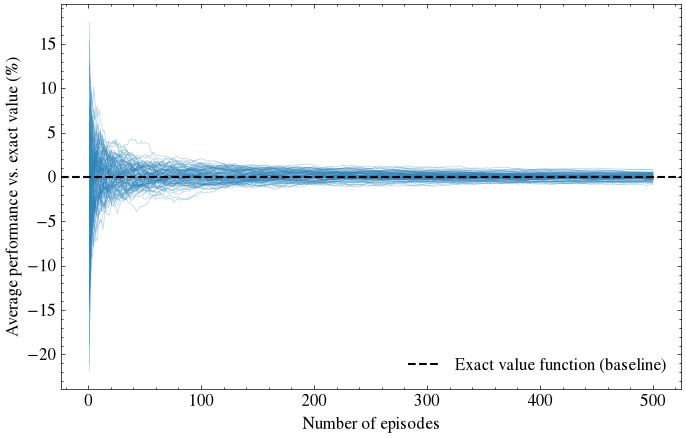

Running exact value function convergence for 3 warehouses, 50 customers, uneven capacity distribution


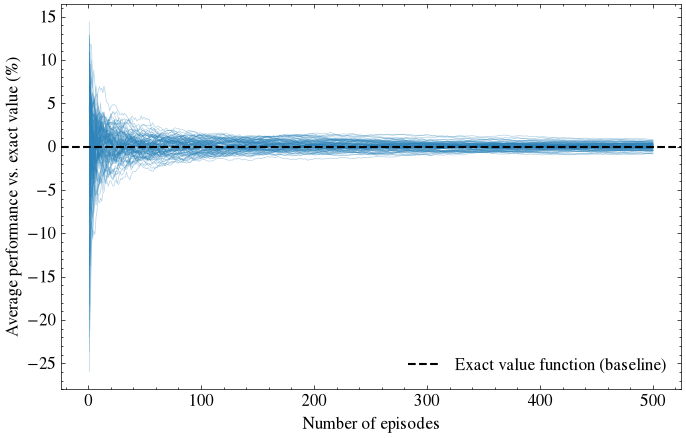

Running exact value function convergence for 4 warehouses, 50 customers, uniform capacity distribution


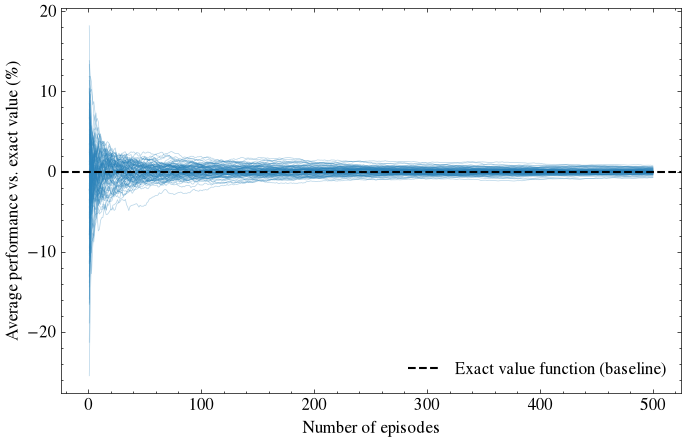

Running exact value function convergence for 4 warehouses, 50 customers, uneven capacity distribution


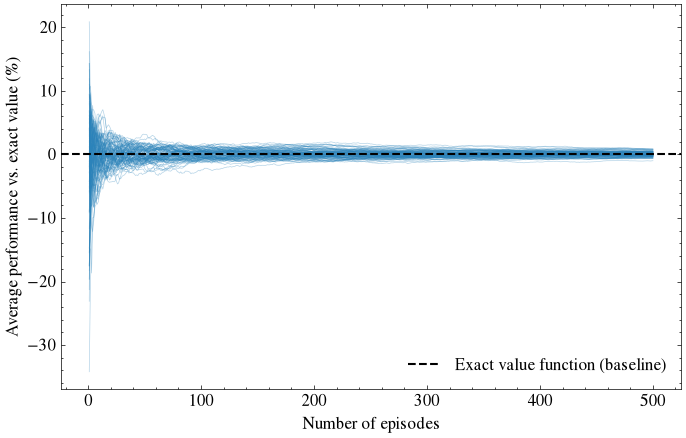

Running exact value function convergence for 5 warehouses, 50 customers, uniform capacity distribution


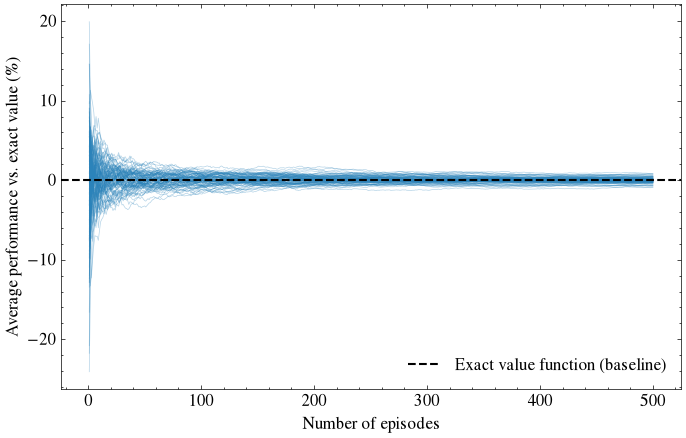

Running exact value function convergence for 5 warehouses, 50 customers, uneven capacity distribution


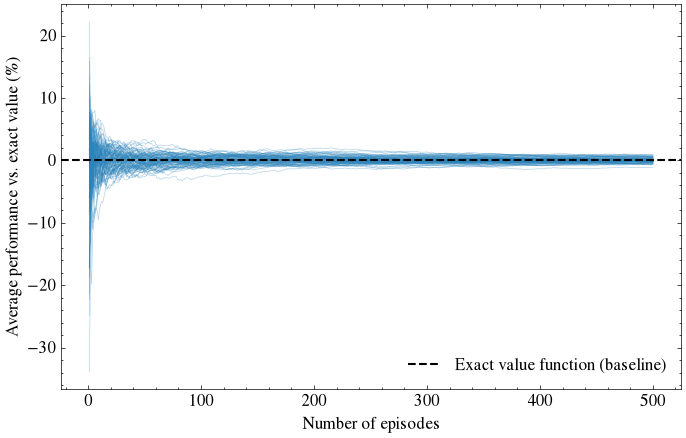

In [9]:

def plot_exact_value_function_convergence(num_warehouses, num_customers, capacity_distribution, baseline, running_averages, out_dir, as_percentage=False):
    # as_percentage: if True, y-axis shows % deviation from the exact baseline; if False, y-axis shows raw reward values.
    num_episodes = running_averages.shape[1]
    episodes = np.arange(1, num_episodes + 1)
    line_color = get_colors(1)[0]

    if as_percentage:
        plot_curves = 100 * (running_averages - baseline) / abs(baseline)
        plot_baseline = 0.0
        ylabel = 'Average performance vs. exact value (%)'
    else:
        plot_curves = running_averages
        plot_baseline = baseline
        ylabel = 'Average performance'

    plt.figure(figsize=(8, 5))
    for rep_curve in plot_curves:
        plt.plot(episodes, rep_curve, color=line_color, alpha=0.35, linewidth=0.5)
    plt.axhline(plot_baseline, color='black', linestyle='--', linewidth=1.5, label='Exact value function (baseline)')

    #plt.title(f'{num_warehouses} facilities - {capacity_distribution} capacity distribution', fontweight='bold', fontsize=TITLE_FONT_SIZE)
    plt.xlabel('Number of episodes', fontsize=FONT_SIZE_LABEL)
    plt.ylabel(ylabel, fontsize=FONT_SIZE_LABEL)
    plt.xticks(fontsize=FONT_SIZE_TICK)
    plt.yticks(fontsize=FONT_SIZE_TICK)
    plt.legend(fontsize=FONT_SIZE_LEGEND, loc='lower right')
    plt.grid(False)

    os.makedirs(out_dir, exist_ok=True)
    suffix = '_pct' if as_percentage else ''
    plt.savefig(f'{out_dir}/exact_value_function_convergence_w_{num_warehouses}_c_{num_customers}_d_{capacity_distribution}{suffix}.pdf', dpi=600, bbox_inches='tight')
    plt.show()

EVF_NUM_CUSTOMERS = 50
EVF_OUT_DIR = 'training/exact_value_function_training/plots'
EVF_AS_PERCENTAGE = True  # toggle: True -> y-axis is % deviation from the exact baseline, False -> raw reward

# Uses the evact_value_function_convergence function to run the exact value function convergence for different numbers of warehouses and capacity distributions, and then plots the results.
for num_warehouses in [2, 3, 4, 5]:
    for capacity_distribution in ['uniform', 'uneven']:
        print(f'Running exact value function convergence for {num_warehouses} warehouses, {EVF_NUM_CUSTOMERS} customers, {capacity_distribution} capacity distribution')
        baseline, running_averages = exact_value_function_convergence(num_warehouses, EVF_NUM_CUSTOMERS, capacity_distribution)
        plot_exact_value_function_convergence(num_warehouses, EVF_NUM_CUSTOMERS, capacity_distribution, baseline, running_averages, EVF_OUT_DIR, as_percentage=EVF_AS_PERCENTAGE)


# Figure C.14 -> Impact of number of episodes in the quality of approximation of the expectation

,facilities,distribution,baseline,episode_std,CV (%),95% CI half-width @ N=10 (%),95% CI half-width @ N=20 (%),95% CI half-width @ N=50 (%),95% CI half-width @ N=100 (%),95% CI half-width @ N=200 (%),95% CI half-width @ N=300 (%)
0,2,uniform,-3271.88,235.86,7.21,4.47,3.16,2.00,1.41,1.00,0.82
1,2,uneven,-3492.05,247.98,7.10,4.40,3.11,1.97,1.39,0.98,0.80
2,3,uniform,-2635.51,206.88,7.85,4.87,3.44,2.18,1.54,1.09,0.89
3,3,uneven,-2869.43,240.56,8.38,5.20,3.67,2.32,1.64,1.16,0.95
4,4,uniform,-2206.67,161.59,7.32,4.54,3.21,2.03,1.44,1.01,0.83
5,4,uneven,-2515.38,220.17,8.75,5.43,3.84,2.43,1.72,1.21,0.99
6,5,uniform,-2098.33,162.64,7.75,4.80,3.40,2.15,1.52,1.07,0.88
7,5,uneven,-2208.84,186.78,8.46,5.24,3.71,2.34,1.66,1.17,0.96


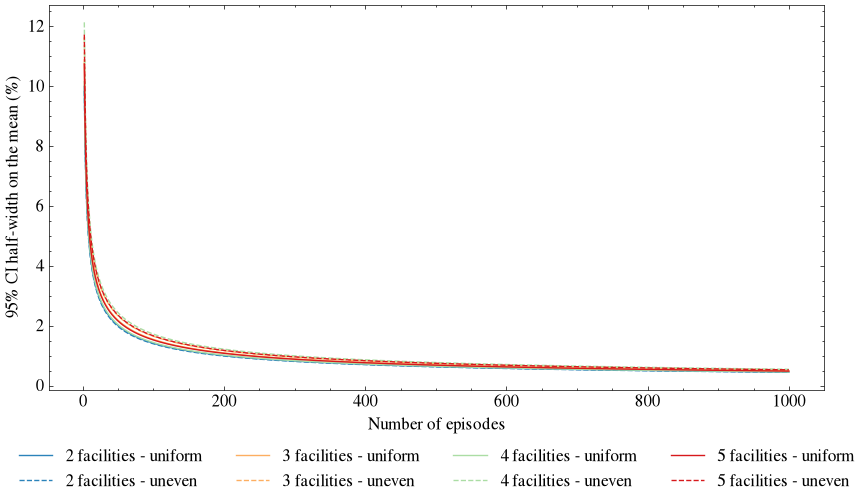

In [10]:
# Define the number of sample episodes, seed, and choices of N for the analysis of the exact value function policy's performance.
EVF_ANALYSIS_NUM_SAMPLE_EPISODES = 10000
EVF_ANALYSIS_SEED = 123
EVF_ANALYSIS_N_CHOICES = [10, 20, 50, 100, 200, 300]

analysis_rows = []
for num_warehouses in [2, 3, 4, 5]:
    for capacity_distribution in ['uniform', 'uneven']:
        env = InventoryEnv(num_warehouses, EVF_NUM_CUSTOMERS, capacity_distribution, grid_size=200)
        env.set_instance(None)
        policy = ExactValueFunctionPolicy(env, num_warehouses, EVF_NUM_CUSTOMERS, capacity_distribution)

        # Get the baseline value of the exact value function policy for the initial state of the environment.
        baseline = policy.values[aggregate_state(tuple(env.warehouses_initial_capacity), policy.aggregation)]

        # Set seed for reproducibility and run multiple episodes to sample rewards from the exact value function policy.
        env.set_seed(EVF_ANALYSIS_SEED)
        sample_rewards = np.array([run_exact_value_function_episode(env, policy) for _ in range(EVF_ANALYSIS_NUM_SAMPLE_EPISODES)])

        # Get the optimal policy sandwich reward and compute the standard deviation and coefficient of variation of the sampled rewards.
        episode_std = sample_rewards.std(ddof=1)
        cv_pct = 100 * episode_std / abs(baseline)  # coefficient of variation of a single episode's reward, relative to |baseline|

        row = {
            'facilities': num_warehouses,
            'distribution': capacity_distribution,
            'baseline': baseline,
            'episode_std': episode_std,
            'CV (%)': cv_pct,
        }

        # Get the 95% confidence interval half-width for different choices of N (number of episodes) and store them in the row.
        for n in EVF_ANALYSIS_N_CHOICES:
            row[f'95% CI half-width @ N={n} (%)'] = 1.96 * cv_pct / np.sqrt(n)
        analysis_rows.append(row)

evf_analysis_df = pd.DataFrame(analysis_rows)
display(evf_analysis_df.round(2))

warehouse_colors = dict(zip([2, 3, 4, 5], get_colors(4)))
distribution_linestyles = {'uniform': '-', 'uneven': '--'}

# Plot the 95% confidence interval half-width curves for different numbers of warehouses and capacity distributions, as a function of the number of episodes (N).
plt.figure(figsize=(10, 5))
n_grid = np.arange(2, 1001)
for row in analysis_rows:
    half_width_curve = 1.96 * row['CV (%)'] / np.sqrt(n_grid)
    plt.plot(
        n_grid, half_width_curve,
        label=f"{row['facilities']} facilities - {row['distribution']}",
        color=warehouse_colors[row['facilities']],
        linestyle=distribution_linestyles[row['distribution']],
    )
    
plt.xlabel('Number of episodes', fontsize=FONT_SIZE_LABEL)
plt.ylabel('95% CI half-width on the mean (%)', fontsize=FONT_SIZE_LABEL)
plt.xticks(fontsize=FONT_SIZE_TICK)
plt.yticks(fontsize=FONT_SIZE_TICK)
plt.legend(fontsize=FONT_SIZE_LEGEND, loc='lower center', bbox_to_anchor=(0.5, -0.30), ncol=4)
plt.grid(False)

# Save the plot to a file
os.makedirs(EVF_OUT_DIR, exist_ok=True)
plt.savefig(f'{EVF_OUT_DIR}/exact_value_function_required_N_analysis.pdf', dpi=600, bbox_inches='tight')
plt.show()

# Figure B.12 -> Analysis of the impact of map discretization in the calculated value of the post-decision states

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


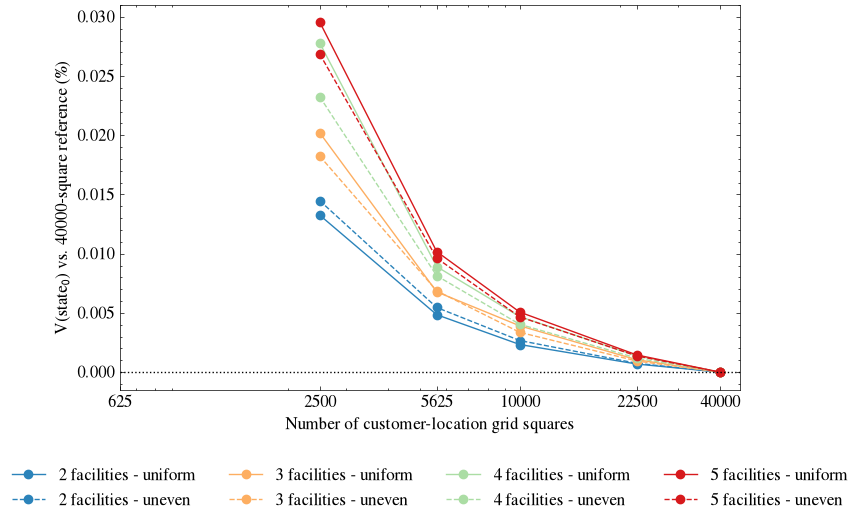

In [11]:
# Selects the num_squares included in the analysis and sets the reference number of squares for comparison.
NUM_SQUARES_LIST = [625, 2500, 5625, 10000, 22500, 40000]
REFERENCE_NUM_SQUARES = 40000

# Reads the square_test.csv file, filters it to include only the selected num_squares, and computes the percentage difference of the initial value function from the reference value function for each combination of num_warehouses and capacity_distribution.
square_test_df = pd.read_csv('training/exact_value_function_training/square_test.csv')
square_test_df = square_test_df[square_test_df['num_squares'].isin(NUM_SQUARES_LIST)]

reference = square_test_df[square_test_df['num_squares'] == REFERENCE_NUM_SQUARES] \
    .set_index(['num_warehouses', 'capacity_distribution'])['initial_value']
square_test_df['reference_value'] = square_test_df.apply(
    lambda r: reference[(r['num_warehouses'], r['capacity_distribution'])], axis=1)
square_test_df['pct_diff_to_reference'] = 100 * (square_test_df['initial_value'] - square_test_df['reference_value']) / abs(square_test_df['reference_value'])

warehouse_colors = dict(zip([2, 3, 4, 5], get_colors(4)))
distribution_linestyles = {'uniform': '-', 'uneven': '--'}

# Plots the percentage difference of the initial value function from the reference value function against the number of squares for each combination of num_warehouses and capacity_distribution.
plt.figure(figsize=(8, 5))
for num_warehouses in [2, 3, 4, 5]:
    for capacity_distribution in ['uniform', 'uneven']:
        sub = square_test_df[(square_test_df['num_warehouses'] == num_warehouses) &
                              (square_test_df['capacity_distribution'] == capacity_distribution)].sort_values('num_squares')
        plt.plot(
            sub['num_squares'], sub['pct_diff_to_reference'],
            marker='o',
            color=warehouse_colors[num_warehouses],
            linestyle=distribution_linestyles[capacity_distribution],
            label=f'{num_warehouses} facilities - {capacity_distribution}',
        )

plt.axhline(0.0, color='black', linestyle=':', linewidth=1.0)
plt.xscale('log')
plt.xticks(NUM_SQUARES_LIST, [str(n) for n in NUM_SQUARES_LIST], fontsize=FONT_SIZE_TICK)
plt.yticks(fontsize=FONT_SIZE_TICK)
plt.xlabel('Number of customer-location grid squares', fontsize=FONT_SIZE_LABEL)
plt.ylabel(f'V(state$_0$) vs. {REFERENCE_NUM_SQUARES}-square reference (%)', fontsize=FONT_SIZE_LABEL)
plt.legend(fontsize=FONT_SIZE_LEGEND, loc='lower center', bbox_to_anchor=(0.5, -0.35), ncol=4)
plt.grid(False)

# Save the plot to a file
EVF_SQUARES_OUT_DIR = 'training/exact_value_function_training/plots'
os.makedirs(EVF_SQUARES_OUT_DIR, exist_ok=True)
plt.savefig(f'{EVF_SQUARES_OUT_DIR}/exact_value_function_initial_value_num_squares_sensitivity.pdf', dpi=600, bbox_inches='tight')
plt.show()